In [ ]:

# БЛОК 1: ИМПОРТ БИБЛИОТЕК И НАСТРОЙКА

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import random
from faker import Faker
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

# Фиксация seed для воспроизводимости
np.random.seed(42)
random.seed(42)

print("Библиотеки успешно загружены")
print(f"Seed фиксирован: 42")


# БЛОК 2: ОПРЕДЕЛЕНИЕ КАТЕГОРИЙ И MCC-КОДОВ

MCC_CATEGORIES = {
    # Питание (5 кодов)
    'Продукты': ['5411', '5499', '5422', '5441', '5451'],
    'Рестораны': ['5812', '5813', '5815', '5811', '5814'],
    'Фастфуд': ['5814', '5815', '5816'],
    'Бары и ночные клубы': ['5813', '5814', '5812'],

    # Транспорт (5 кодов)
    'АЗС': ['5541', '5542', '5543', '5532', '5533'],
    'Транспорт': ['4111', '4112', '4131', '4121', '4119'],
    'Такси': ['4121', '5999'],
    'Авиабилеты': ['4511', '4512', '4513', '4723'],
    'Ж/Д билеты': ['4011', '4112'],
    'Аренда авто': ['7512', '7513', '7511', '7519'],

    # Проживание (4 кода)
    'Отели': ['7011', '7012', '3501', '3502', '3503'],

    # Коммунальные и связь (4 кода)
    'Коммунальные услуги': ['4900', '4814', '4815', '4816', '4899'],
    'Связь': ['4814', '4815', '4816', '4899', '4821'],

    # Развлечения (5 кодов)
    'Развлечения': ['7997', '7994', '7996', '7991', '7998', '7922', '7941', '7832'],

    # Здоровье и красота (4 кода)
    'Аптеки': ['5912', '5911', '5913'],
    'Красота': ['5970', '5971', '5972', '7230', '7299'],
    'Медицинские услуги': ['8090', '8011', '8021', '8041', '8042', '8043'],

    # Покупки (по 3-5 кодов на каждую)
    'Универмаги': ['5311', '5310', '5399', '5331'],
    'Одежда': ['5611', '5621', '5631', '5641', '5651', '5661', '5691', '5699'],
    'Обувь': ['5661', '5139', '5137'],
    'Хобби': ['5945', '5940', '5941', '5942', '5943', '5944', '5946', '5947', '5948', '5949'],
    'Электроника': ['5732', '5733', '5734', '5735', '4812'],
    'Ювелирные изделия': ['5944', '5094', '5947'],
    'Товары для дома': ['5200', '5211', '5231', '5712', '5713', '5714', '5718', '5719'],
    'Мебель': ['5712', '5713', '5714', '5718', '5719'],
    'Товары для ремонта': ['5211', '5231', '5251', '5261'],
    'Товары для животных': ['5995', '5999', '5994'],
    'Книги': ['5942', '5943', '5999'],

    # Образование (3 кода)
    'Образование': ['8211', '8220', '8241', '8244', '8249', '8299'],

    # Прочее (5 кодов)
    'Прочее': ['5999', '7299', '7399', '7999', '8999']
}

# Преобразуем в плоский словарь для удобного доступа
MCC_TO_CATEGORY = {}
for category, mcc_list in MCC_CATEGORIES.items():
    for mcc in mcc_list:
        MCC_TO_CATEGORY[mcc] = category

# Уникальные категории
CATEGORIES = sorted(list(MCC_CATEGORIES.keys()))

print("Определены категории с множественными MCC-кодами")
print(f"Всего категорий: {len(CATEGORIES)}")
print("\n Примеры категорий с MCC-кодами:")
for cat in list(CATEGORIES)[:10]:
    mcc_codes = MCC_CATEGORIES[cat]
    print(f"   {cat}: {', '.join(mcc_codes[:3])}{'...' if len(mcc_codes) > 3 else ''} ({len(mcc_codes)} кодов)")

# Статистика по MCC-кодам
total_mcc = sum(len(mcc_list) for mcc_list in MCC_CATEGORIES.values())
print(f"\n Всего MCC-кодов: {total_mcc}")

# БЛОК 3: РЕАЛИСТИЧНЫЕ ДИАПАЗОНЫ СУММ ТРАНЗАКЦИЙ

CATEGORY_AMOUNT_RANGES = {
    'Продукты': {'min': 150, 'max': 10000, 'typical': (500, 2000)},
    'Рестораны': {'min': 1000, 'max': 15000, 'typical': (3000, 7000)},
    'Фастфуд': {'min': 150, 'max': 1200, 'typical': (300, 600)},
    'Бары и ночные клубы': {'min': 500, 'max': 15000, 'typical': (1500, 5000)},
    'АЗС': {'min': 1200, 'max': 7000, 'typical': (2000, 5000)},
    'Транспорт': {'min': 40, 'max': 300, 'typical': (50, 150)},
    'Такси': {'min': 300, 'max': 10000, 'typical': (600, 1500)},
    'Авиабилеты': {'min': 3000, 'max': 80000, 'typical': (8000, 25000)},
    'Ж/Д билеты': {'min': 1000, 'max': 25000, 'typical': (4000, 8000)},
    'Аренда авто': {'min': 1000, 'max': 20000, 'typical': (3000, 8000)},
    'Отели': {'min': 2000, 'max': 35000, 'typical': (4000, 12000)},
    'Коммунальные услуги': {'min': 1000, 'max': 20000, 'typical': (3000, 7000)},
    'Связь': {'min': 300, 'max': 5000, 'typical': (500, 1500)},
    'Развлечения': {'min': 300, 'max': 8000, 'typical': (800, 3000)},
    'Аптеки': {'min': 100, 'max': 8000, 'typical': (300, 2000)},
    'Красота': {'min': 500, 'max': 20000, 'typical': (3400, 9000)},
    'Медицинские услуги': {'min': 500, 'max': 50000, 'typical': (2000, 10000)},
    'Универмаги': {'min': 500, 'max': 30000, 'typical': (1500, 7000)},
    'Одежда': {'min': 1500, 'max': 60000, 'typical': (8000, 15000)},
    'Обувь': {'min': 1500, 'max': 25000, 'typical': (3000, 9000)},
    'Хобби': {'min': 300, 'max': 20000, 'typical': (1000, 5000)},
    'Электроника': {'min': 1000, 'max': 200000, 'typical': (5000, 30000)},
    'Ювелирные изделия': {'min': 2000, 'max': 200000, 'typical': (10000, 50000)},
    'Товары для дома': {'min': 200, 'max': 20000, 'typical': (500, 3000)},
    'Мебель': {'min': 1000, 'max': 100000, 'typical': (5000, 20000)},
    'Товары для ремонта': {'min': 200, 'max': 30000, 'typical': (1500, 5000)},
    'Товары для животных': {'min': 200, 'max': 8000, 'typical': (500, 2000)},
    'Книги': {'min': 200, 'max': 5000, 'typical': (500, 1500)},
    'Образование': {'min': 1000, 'max': 500000, 'typical': (20000, 70000)},
    'Прочее': {'min': 1000, 'max': 100000, 'typical': (2000, 15000)}
}

def generate_realistic_amount(category):
    """Генерация реалистичной суммы транзакции"""
    import random

    if category in CATEGORY_AMOUNT_RANGES:
        ranges = CATEGORY_AMOUNT_RANGES[category]
        min_amt = ranges['min']
        max_amt = ranges['max']
        typical_min, typical_max = ranges['typical']
        typical_mean = (typical_min + typical_max) / 2
    else:
        min_amt = 100
        max_amt = 5000
        typical_mean = 500

    mu = np.log(typical_mean)
    sigma = 0.5
    amount = random.lognormvariate(mu, sigma)
    amount = max(min_amt, min(max_amt, amount))

    if category in ['Транспорт', 'Фастфуд']:
        amount = int(round(amount))
    else:
        amount = int(round(amount / 10) * 10)

    return amount

print("Функция generate_realistic_amount определена")

Библиотеки успешно загружены
Seed фиксирован: 42
Определены категории с множественными MCC-кодами
Всего категорий: 30

 Примеры категорий с MCC-кодами:
   АЗС: 5541, 5542, 5543... (5 кодов)
   Авиабилеты: 4511, 4512, 4513... (4 кодов)
   Аптеки: 5912, 5911, 5913 (3 кодов)
   Аренда авто: 7512, 7513, 7511... (4 кодов)
   Бары и ночные клубы: 5813, 5814, 5812 (3 кодов)
   Ж/Д билеты: 4011, 4112 (2 кодов)
   Книги: 5942, 5943, 5999 (3 кодов)
   Коммунальные услуги: 4900, 4814, 4815... (5 кодов)
   Красота: 5970, 5971, 5972... (5 кодов)
   Мебель: 5712, 5713, 5714... (5 кодов)

 Всего MCC-кодов: 142
Функция generate_realistic_amount определена


In [ ]:
!pip install faker

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 41.3 MB/s eta 0:00:00


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.6 MB/s eta 0:00:00


In [ ]:

# БЛОК 4: ГЕНЕРАЦИЯ ПРОФИЛЕЙ КЛИЕНТОВ
NUM_CUSTOMERS = 15000

# Целевое распределение по сегментам
SEGMENT_DISTRIBUTION = {
    'premium_active': 0.12,     # 1800 клиентов
    'premium_inactive': 0.08,   # 1200 клиентов
    'active': 0.25,             # 3750 клиентов
    'regular': 0.30,            # 4500 клиентов
    'inactive': 0.20,           # 3000 клиентов
    'new': 0.05                 # 750 клиентов
}

def generate_customer_profile(customer_id, segment_type=None):
    """Генерация профиля клиента с заданным сегментом"""
    fake = Faker('ru_RU')

    if segment_type is None:
        segment_type = np.random.choice(
            list(SEGMENT_DISTRIBUTION.keys()),
            p=list(SEGMENT_DISTRIBUTION.values())
        )

    age = np.random.randint(18, 71)
    gender = np.random.choice(['Male', 'Female'])
    city = np.random.choice(['Москва', 'Санкт-Петербург', 'Регион'], p=[0.3, 0.2, 0.5])
    num_products = np.random.choice([1, 2, 3, 4], p=[0.4, 0.35, 0.2, 0.05])
    has_credit_card = np.random.choice([0, 1], p=[0.3, 0.7])

    if segment_type == 'premium_active':
        salary = np.random.randint(150000, 500000)
        is_active = 1
        credit_score = int(np.random.normal(750, 80))
        tenure = np.random.randint(12, 121)
        num_products = np.random.choice([2, 3, 4], p=[0.2, 0.5, 0.3])

    elif segment_type == 'premium_inactive':
        salary = np.random.randint(150000, 500000)
        is_active = 0
        credit_score = int(np.random.normal(720, 90))
        tenure = np.random.randint(6, 61)

    elif segment_type == 'active':
        salary = np.random.randint(50000, 150000)
        is_active = 1
        credit_score = int(np.random.normal(680, 100))
        tenure = np.random.randint(6, 61)

    elif segment_type == 'regular':
        salary = np.random.randint(30000, 90000)
        is_active = np.random.choice([0, 1], p=[0.3, 0.7])
        credit_score = int(np.random.normal(650, 100))
        tenure = np.random.randint(1, 61)

    elif segment_type == 'inactive':
        salary = np.random.randint(20000, 70000)
        is_active = 0
        credit_score = int(np.random.normal(600, 110))
        tenure = np.random.randint(1, 61)

    else:  # new
        salary = np.random.randint(25000, 100000)
        is_active = 1
        credit_score = int(np.random.normal(650, 100))
        tenure = np.random.randint(0, 4)

    credit_score = max(300, min(850, credit_score))

    return {
        'customer_id': customer_id,
        'age': age,
        'gender': gender,
        'estimated_salary': salary,
        'credit_score': credit_score,
        'city': city,
        'tenure': tenure,
        'num_products': num_products,
        'has_credit_card': has_credit_card,
        'is_active_member': is_active,
        'segment_type': segment_type
    }

print("Генерация профилей клиентов...")
customers = []

for seg, proportion in SEGMENT_DISTRIBUTION.items():
    n_seg = int(NUM_CUSTOMERS * proportion)
    for i in range(n_seg):
        cust_id = f'CUST_{len(customers):06d}'
        customers.append(generate_customer_profile(cust_id, seg))

# Добиваем до нужного количества
while len(customers) < NUM_CUSTOMERS:
    cust_id = f'CUST_{len(customers):06d}'
    customers.append(generate_customer_profile(cust_id, 'regular'))

df_customers = pd.DataFrame(customers)

print(f"Сгенерировано профилей: {len(df_customers):,}")
print("\nРаспределение по сегментам:")
for seg, count in df_customers['segment_type'].value_counts().items():
    print(f"   {seg}: {count:,} клиентов ({count/len(df_customers)*100:.1f}%)")

Генерация профилей клиентов...
Сгенерировано профилей: 15,000

Распределение по сегментам:
   regular: 4,500 клиентов (30.0%)
   active: 3,750 клиентов (25.0%)
   inactive: 3,000 клиентов (20.0%)
   premium_active: 1,800 клиентов (12.0%)
   premium_inactive: 1,200 клиентов (8.0%)
   new: 750 клиентов (5.0%)


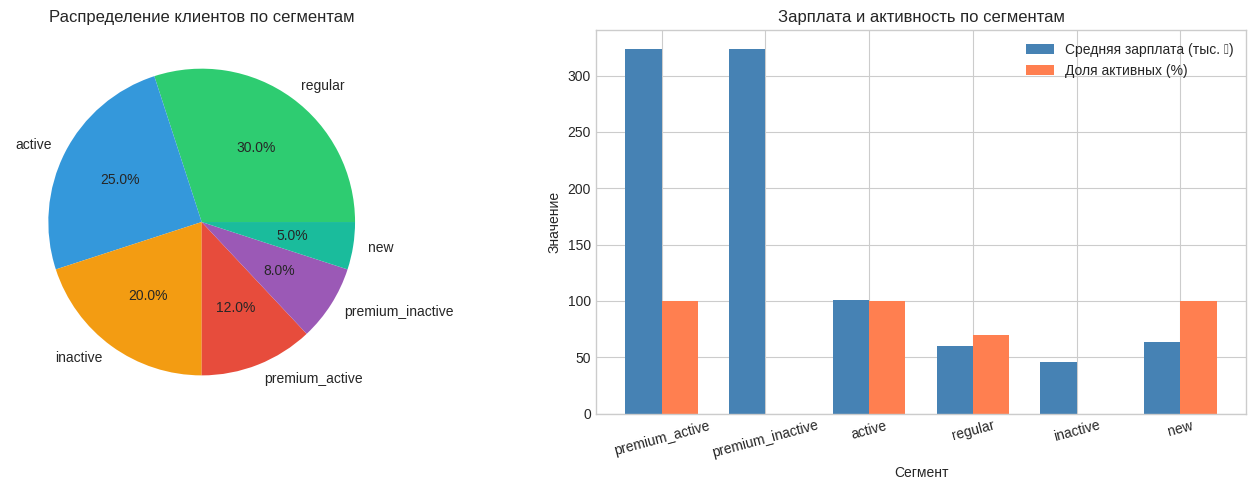

In [ ]:

# БЛОК 5: ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЯ КЛИЕНТОВ ПО СЕГМЕНТАМ

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Распределение сегментов
segment_counts = df_customers['segment_type'].value_counts()
colors = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c', '#9b59b6', '#1abc9c']
axes[0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Распределение клиентов по сегментам', fontsize=12)

# График 2: Средняя зарплата и активность по сегментам
segments = df_customers['segment_type'].unique()
avg_salary = []
active_pct = []

for seg in segments:
    seg_data = df_customers[df_customers['segment_type'] == seg]
    avg_salary.append(seg_data['estimated_salary'].mean() / 1000)
    active_pct.append(seg_data['is_active_member'].mean() * 100)

x = np.arange(len(segments))
width = 0.35

axes[1].bar(x - width/2, avg_salary, width, label='Средняя зарплата (тыс. ₽)', color='steelblue')
axes[1].bar(x + width/2, active_pct, width, label='Доля активных (%)', color='coral')
axes[1].set_xlabel('Сегмент')
axes[1].set_ylabel('Значение')
axes[1].set_title('Зарплата и активность по сегментам', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(segments, rotation=15)
axes[1].legend()

plt.tight_layout()
plt.savefig('customer_segments.png', dpi=150)
plt.show()

In [ ]:

# БЛОК 6: ГЕНЕРАЦИЯ ТРАНЗАКЦИОННОЙ ИСТОРИИ
# ПЕРИОД: 01.09.2025 - 30.04.2026

print("ГЕНЕРАЦИЯ ТРАНЗАКЦИОННОЙ ИСТОРИИ")
print("Период: 01.09.2025 - 30.04.2026")

# Параметры для разных сегментов
SEGMENT_PARAMS = {
    'premium_active': {
        'spend_ratio': (0.35, 0.65),
        'tx_multiplier': 1.6,
        'large_purchase_prob': 0.18,
        'night_tx_prob': 0.12
    },
    'premium_inactive': {
        'spend_ratio': (0.10, 0.25),
        'tx_multiplier': 0.25,
        'large_purchase_prob': 0.05,
        'night_tx_prob': 0.05
    },
    'active': {
        'spend_ratio': (0.25, 0.50),
        'tx_multiplier': 1.3,
        'large_purchase_prob': 0.12,
        'night_tx_prob': 0.10
    },
    'regular': {
        'spend_ratio': (0.15, 0.40),
        'tx_multiplier': 0.9,
        'large_purchase_prob': 0.08,
        'night_tx_prob': 0.08
    },
    'inactive': {
        'spend_ratio': (0.05, 0.15),
        'tx_multiplier': 0.2,
        'large_purchase_prob': 0.03,
        'night_tx_prob': 0.04
    },
    'new': {
        'spend_ratio': (0.30, 0.60),
        'tx_multiplier': 1.2,
        'large_purchase_prob': 0.09,
        'night_tx_prob': 0.08
    }
}

def get_favorite_categories(age, salary, city, segment):
    """Определение любимых категорий на основе возраста, дохода, города и сегмента"""
    favorite_categories = []

    if segment in ['premium_active', 'premium_inactive']:
        favorite_categories.extend(['Рестораны', 'Отели', 'Авиабилеты', 'Ювелирные изделия', 'Электроника'])
        if age < 40:
            favorite_categories.extend(['Бары и ночные клубы', 'Развлечения'])
        else:
            favorite_categories.extend(['Медицинские услуги', 'Образование'])
    else:
        if age < 30:
            favorite_categories.extend(['Фастфуд', 'Развлечения', 'Такси', 'Транспорт', 'Одежда'])
            if salary > 80000:
                favorite_categories.extend(['Рестораны', 'Отели'])
        elif age < 45:
            favorite_categories.extend(['Продукты', 'Рестораны', 'АЗС', 'Товары для дома', 'Одежда'])
            if salary > 100000:
                favorite_categories.extend(['Отели', 'Электроника'])
        elif age < 60:
            favorite_categories.extend(['Продукты', 'Аптеки', 'Коммунальные услуги', 'Товары для дома', 'Товары для животных'])
            if salary > 80000:
                favorite_categories.extend(['Рестораны', 'Отели'])
        else:
            favorite_categories.extend(['Продукты', 'Аптеки', 'Коммунальные услуги', 'Связь', 'Медицинские услуги'])

    if city == 'Москва':
        favorite_categories.extend(['Такси', 'Рестораны'])
        if segment in ['premium_active', 'premium_inactive']:
            favorite_categories.extend(['Авиабилеты', 'Отели'])
    elif city == 'Санкт-Петербург':
        favorite_categories.extend(['Развлечения', 'Красота'])

    return list(set(favorite_categories))

def generate_realistic_amount(category):
    """Генерация реалистичной суммы транзакции"""
    import random

    if category in CATEGORY_AMOUNT_RANGES:
        ranges = CATEGORY_AMOUNT_RANGES[category]
        min_amt = ranges['min']
        max_amt = ranges['max']
        typical_min, typical_max = ranges['typical']
        typical_mean = (typical_min + typical_max) / 2
    else:
        min_amt = 100
        max_amt = 5000
        typical_mean = 500

    mu = np.log(typical_mean)
    sigma = 0.5
    amount = random.lognormvariate(mu, sigma)
    amount = max(min_amt, min(max_amt, amount))

    if category in ['Транспорт', 'Фастфуд']:
        amount = int(round(amount))
    else:
        amount = int(round(amount / 10) * 10)

    return amount

def generate_transactions_for_customer(customer, start_date='2025-09-01', end_date='2026-04-30'):
    """
    Генерация транзакций для одного клиента

    Правила:
    - Активные клиенты: транзакции за весь период (сентябрь-апрель)
    - Неактивные клиенты: транзакции только до 31 марта 2026
    """

    customer_id = customer['customer_id']
    salary = customer['estimated_salary']
    age = customer['age']
    city = customer['city']
    is_active = customer['is_active_member']
    segment = customer.get('segment_type', 'regular')

    start_dt = datetime.strptime(start_date, '%Y-%m-%d')

    # Определяем конечную дату в зависимости от активности
    if segment in ['inactive', 'premium_inactive'] or is_active == 0:
        end_dt = datetime(2026, 3, 31, 23, 59, 59)
    else:
        end_dt = datetime.strptime(end_date, '%Y-%m-%d')
        end_dt = end_dt.replace(hour=23, minute=59, second=59)

    params = SEGMENT_PARAMS.get(segment, SEGMENT_PARAMS['regular'])

    spend_min, spend_max = params['spend_ratio']
    base_monthly_spend = salary * np.random.uniform(spend_min, spend_max)

    if is_active == 0:
        base_monthly_spend *= np.random.uniform(0.1, 0.3)

    favorite_categories = get_favorite_categories(age, salary, city, segment)

    categories = favorite_categories.copy()
    other_cats = [c for c in CATEGORIES if c not in categories]
    num_extra = min(5, len(other_cats))
    if num_extra > 0:
        categories.extend(np.random.choice(other_cats, num_extra, replace=False))

    weights = []
    for cat in categories:
        if cat in favorite_categories:
            weights.append(np.random.uniform(0.06, 0.20))
        else:
            weights.append(np.random.uniform(0.01, 0.05))

    weights = np.array(weights) / np.sum(weights)
    category_weights = dict(zip(categories, weights))

    transactions = []

    current_date = start_dt
    while current_date <= end_dt:
        year = current_date.year
        month = current_date.month

        # Количество дней в месяце
        if month == 12:
            days_in_month = 31
        else:
            next_month = datetime(year, month + 1, 1) if month < 12 else datetime(year + 1, 1, 1)
            days_in_month = (next_month - datetime(year, month, 1)).days

        base_tx = max(3, min(40, int(salary / 30000)))
        num_tx = int(np.random.poisson(lam=base_tx * params['tx_multiplier']))
        num_tx = max(1, min(60, num_tx))

        for _ in range(num_tx):
            category = np.random.choice(list(category_weights.keys()), p=list(category_weights.values()))
            amount = generate_realistic_amount(category)

            if np.random.random() < params['large_purchase_prob']:
                max_possible = CATEGORY_AMOUNT_RANGES[category]['max']
                amount = int(max_possible * np.random.uniform(0.6, 0.95))

            if salary > 150000:
                amount = int(amount * np.random.uniform(1.0, 1.5))
            elif salary < 40000:
                amount = int(amount * np.random.uniform(0.5, 0.9))

            amount = max(CATEGORY_AMOUNT_RANGES[category]['min'],
                        min(CATEGORY_AMOUNT_RANGES[category]['max'], amount))

            day = np.random.randint(1, days_in_month + 1)

            # Генерация времени транзакции
            component = np.random.choice([0, 1, 2], p=[0.35, 0.35, 0.30])
            if component == 0:
                hour_raw = np.random.normal(10, 1.8)
            elif component == 1:
                hour_raw = np.random.normal(14, 1.8)
            else:
                hour_raw = np.random.normal(19, 1.8)

            if np.random.random() < params['night_tx_prob']:
                hour_raw = np.random.uniform(0, 5.5)

            hour = int(np.clip(hour_raw, 0, 23.99))
            minute = np.random.randint(0, 60)
            second = np.random.randint(0, 60)

            tx_date = datetime(year, month, day, hour, minute, second)

            if tx_date < start_dt or tx_date > end_dt:
                continue

            transactions.append({
                'customer_id': customer_id,
                'transaction_date': tx_date,
                'year': year,
                'month': month,
                'day': day,
                'hour': hour,
                'minute': minute,
                'second': second,
                'weekday': tx_date.weekday(),
                'category': category,
                'amount': amount
            })

        # Переход к следующему месяцу
        if month == 12:
            current_date = datetime(year + 1, 1, 1)
        else:
            current_date = datetime(year, month + 1, 1)

    return pd.DataFrame(transactions)

# Генерация транзакций для всех клиентов
print(" Генерация транзакций...")
print(f"   Период: 01.09.2025 - 30.04.2026")
print(f"   Активные клиенты: транзакции за весь период")
print(f"   Неактивные клиенты: транзакции до 31.03.2026")
print("-"*50)

all_transactions = []

for idx, customer in df_customers.iterrows():
    if idx % 2000 == 0:
        print(f"   Обработано {idx:,}/{len(df_customers):,} клиентов ({idx/len(df_customers)*100:.0f}%)")
    tx_df = generate_transactions_for_customer(customer, '2025-09-01', '2026-04-30')
    all_transactions.append(tx_df)

df_transactions = pd.concat(all_transactions, ignore_index=True)

print(f"\n Сгенерировано транзакций: {len(df_transactions):,}")
print(f" Период: с {df_transactions['transaction_date'].min()} по {df_transactions['transaction_date'].max()}")
print(f" Уникальных клиентов: {df_transactions['customer_id'].nunique()}")
print(f" Категорий: {df_transactions['category'].nunique()}")

# Проверка апрельских транзакций
april_tx = df_transactions[df_transactions['month'] == 4]
print(f"\n Апрельские транзакции: {len(april_tx):,}")

# Проверка по сегментам
print(f"\n Апрельские транзакции по сегментам:")
for seg in df_customers['segment_type'].unique():
    seg_customers = df_customers[df_customers['segment_type'] == seg]['customer_id'].tolist()
    seg_april = april_tx[april_tx['customer_id'].isin(seg_customers)]
    unique_count = seg_april['customer_id'].nunique()
    print(f"   {seg}: {len(seg_april):,} транзакций ({unique_count} клиентов)")

print("\n Первые 5 транзакций:")
df_transactions.head()

ГЕНЕРАЦИЯ ТРАНЗАКЦИОННОЙ ИСТОРИИ
Период: 01.09.2025 - 30.04.2026
 Генерация транзакций...
   Период: 01.09.2025 - 30.04.2026
   Активные клиенты: транзакции за весь период
   Неактивные клиенты: транзакции до 31.03.2026
--------------------------------------------------
   Обработано 0/15,000 клиентов (0%)
   Обработано 2,000/15,000 клиентов (13%)
   Обработано 4,000/15,000 клиентов (27%)
   Обработано 6,000/15,000 клиентов (40%)
   Обработано 8,000/15,000 клиентов (53%)
   Обработано 10,000/15,000 клиентов (67%)
   Обработано 12,000/15,000 клиентов (80%)
   Обработано 14,000/15,000 клиентов (93%)

 Сгенерировано транзакций: 531,339
 Период: с 2025-09-01 00:02:04 по 2026-04-30 23:47:04
 Уникальных клиентов: 15000
 Категорий: 30

 Апрельские транзакции: 57,133

 Апрельские транзакции по сегментам:
   premium_active: 29,674 транзакций (1800 клиентов)
   premium_inactive: 0 транзакций (0 клиентов)
   active: 16,076 транзакций (3750 клиентов)
   regular: 8,753 транзакций (3156 клиентов)
  

,customer_id,transaction_date,year,month,day,hour,minute,second,weekday,category,amount
0,CUST_000000,2025-09-21 07:55:35,2025,9,21,7,55,35,6,Медицинские услуги,9223
1,CUST_000000,2025-09-20 10:37:52,2025,9,20,10,37,52,5,Красота,6234
2,CUST_000000,2025-09-11 11:28:20,2025,9,11,11,28,20,3,Красота,13410
3,CUST_000000,2025-09-11 10:25:20,2025,9,11,10,25,20,3,Авиабилеты,17662
4,CUST_000000,2025-09-12 14:39:15,2025,9,12,14,39,15,4,Товары для ремонта,2517


In [ ]:
df_transactions.head()

,customer_id,transaction_date,year,month,day,hour,minute,second,weekday,category,amount
0,CUST_000000,2025-09-21 07:55:35,2025,9,21,7,55,35,6,Авиабилеты,25370
1,CUST_000000,2025-09-20 10:37:52,2025,9,20,10,37,52,5,Красота,6234
2,CUST_000000,2025-09-11 11:28:20,2025,9,11,11,28,20,3,Красота,13410
3,CUST_000000,2025-09-11 10:25:20,2025,9,11,10,25,20,3,Ювелирные изделия,32113
4,CUST_000000,2025-09-12 14:39:15,2025,9,12,14,39,15,4,Товары для ремонта,2517


In [ ]:

num_rows = len(df_transactions)
print(f"Количество записей в df_transactions: {num_rows:,}")

Количество записей в df_transactions: 531,339


In [ ]:
#Датасет с профилями клиентов
df_customers

,customer_id,age,gender,estimated_salary,credit_score,city,tenure,num_products,has_credit_card,is_active_member,segment_type
0,CUST_000000,56,Female,204886,676,Регион,86,4,1,1,premium_active
1,CUST_000001,53,Female,344027,740,Регион,41,3,1,1,premium_active
2,CUST_000002,38,Male,306730,707,Санкт-Петербург,71,3,1,1,premium_active
3,CUST_000003,64,Female,423538,740,Москва,112,3,1,1,premium_active
4,CUST_000004,38,Male,355041,738,Москва,13,3,1,1,premium_active
...,...,...,...,...,...,...,...,...,...,...,...
14995,CUST_014995,43,Female,54539,687,Москва,3,1,1,1,new
14996,CUST_014996,20,Male,68544,664,Регион,2,3,0,1,new
14997,CUST_014997,38,Female,40967,528,Санкт-Петербург,2,2,1,1,new
14998,CUST_014998,54,Male,69898,600,Регион,3,1,1,1,new


Распределение апрельских транзакций по сегментам:
                transaction_count  unique_customers
segment_type                                       
premium_active              29674              1800
active                      16076              3750
regular                      8753              3156
new                          2630               750


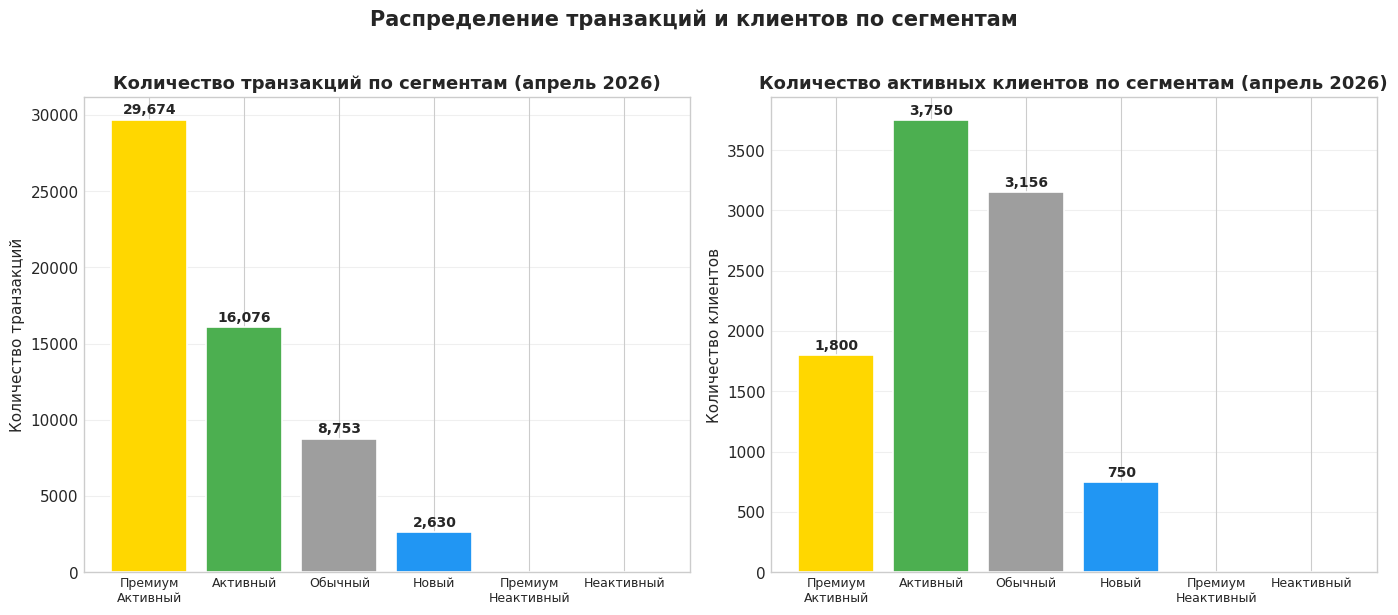

In [ ]:

# ПОДГОТОВКА ДАННЫХ И ВИЗУАЛИЗАЦИЯ

april_tx = df_transactions[df_transactions['month'] == 4]

# Объединяем апрельские транзакции с профилями клиентов
april_by_segment = april_tx.merge(
    df_customers[['customer_id', 'segment_type']],
    on='customer_id',
    how='left'
)

# Статистика по сегментам
segment_stats = april_by_segment.groupby('segment_type').agg(
    transaction_count=('amount', 'size'),
    unique_customers=('customer_id', 'nunique')
).sort_values('transaction_count', ascending=False)

print("Распределение апрельских транзакций по сегментам:")
print(segment_stats)

# ВИЗУАЛИЗАЦИЯ
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

segment_colors = {
    'premium_active': '#FFD700',
    'premium_inactive': '#B0B0B0',
    'active': '#4CAF50',
    'regular': '#9E9E9E',
    'inactive': '#F44336',
    'new': '#2196F3'
}

segments_order = ['premium_active', 'active', 'regular', 'new', 'premium_inactive', 'inactive']
segment_labels = ['Премиум\nАктивный', 'Активный', 'Обычный', 'Новый', 'Премиум\nНеактивный', 'Неактивный']

tx_counts = []
client_counts = []

for seg in segments_order:
    if seg in segment_stats.index:
        tx_counts.append(segment_stats.loc[seg, 'transaction_count'])
        client_counts.append(segment_stats.loc[seg, 'unique_customers'])
    else:
        tx_counts.append(0)
        client_counts.append(0)

colors = [segment_colors[seg] for seg in segments_order]
x = np.arange(len(segments_order))

# График 1: Количество транзакций
bars1 = axes[0].bar(x, tx_counts, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Количество транзакций по сегментам (апрель 2026)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Количество транзакций')
axes[0].set_xticks(x)
axes[0].set_xticklabels(segment_labels, fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

for bar, val in zip(bars1, tx_counts):
    if val > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                    f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# График 2: Количество клиентов
bars2 = axes[1].bar(x, client_counts, color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('Количество активных клиентов по сегментам (апрель 2026)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Количество клиентов')
axes[1].set_xticks(x)
axes[1].set_xticklabels(segment_labels, fontsize=9)
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars2, client_counts):
    if val > 0:
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                    f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Распределение транзакций и клиентов по сегментам', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('april_segments.png', dpi=150, bbox_inches='tight')
plt.show()

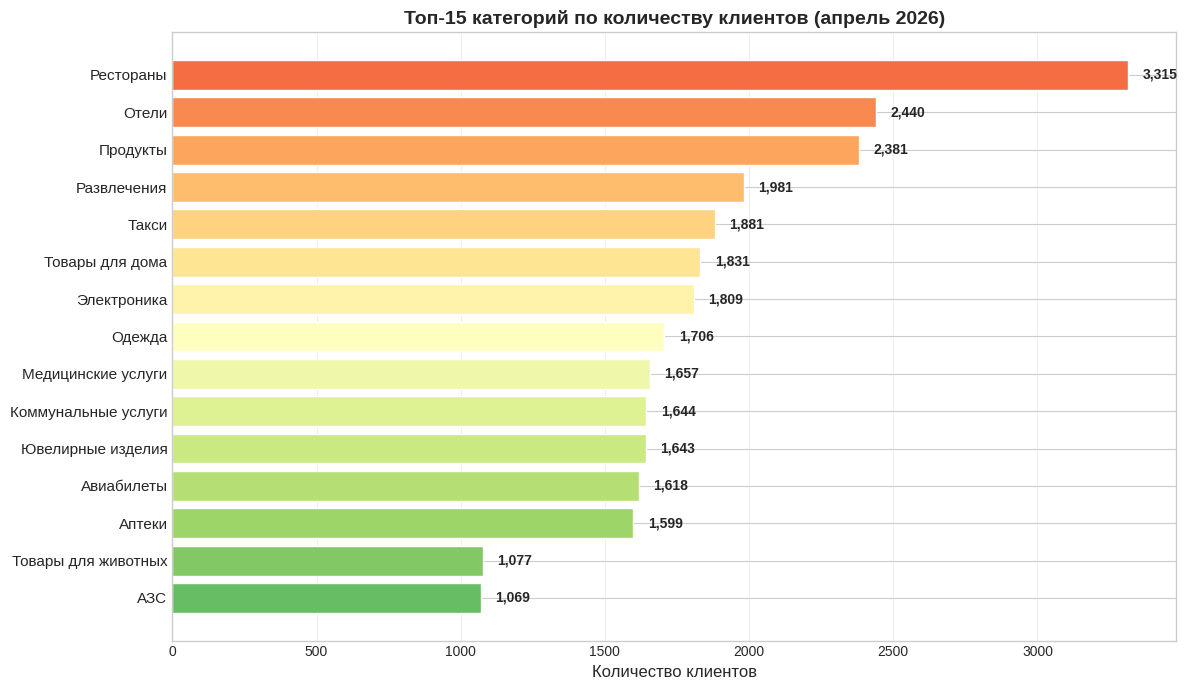

Топ-5 категорий по количеству клиентов в апреле:
  Рестораны                : 3,315 клиентов
  Отели                    : 2,440 клиентов
  Продукты                 : 2,381 клиентов
  Развлечения              : 1,981 клиентов
  Такси                    : 1,881 клиентов


In [ ]:

# ВИЗУАЛИЗАЦИЯ: ТОП КАТЕГОРИЙ ПО КОЛИЧЕСТВУ КЛИЕНТОВ
# (на основе апрельских транзакций, без целевой переменной)


april_tx = df_transactions[df_transactions['month'] == 4]

# Количество уникальных клиентов по категориям в апреле
category_client_counts = april_tx.groupby('category')['customer_id'].nunique().sort_values(ascending=False)

# Топ-15 категорий
top_categories = category_client_counts.head(15)

fig, ax = plt.subplots(figsize=(12, 7))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_categories)))
bars = ax.barh(range(len(top_categories)), top_categories.values, color=colors, edgecolor='white')

ax.set_yticks(range(len(top_categories)))
ax.set_yticklabels(top_categories.index, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel('Количество клиентов', fontsize=12)
ax.set_title('Топ-15 категорий по количеству клиентов (апрель 2026)', fontsize=14, fontweight='bold')

for i, (bar, val) in enumerate(zip(bars, top_categories.values)):
    ax.text(val + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=10, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('top_categories_april.png', dpi=150, bbox_inches='tight')
plt.show()

print("Топ-5 категорий по количеству клиентов в апреле:")
for cat, count in top_categories.head(5).items():
    print(f"  {cat:25s}: {count:,} клиентов")

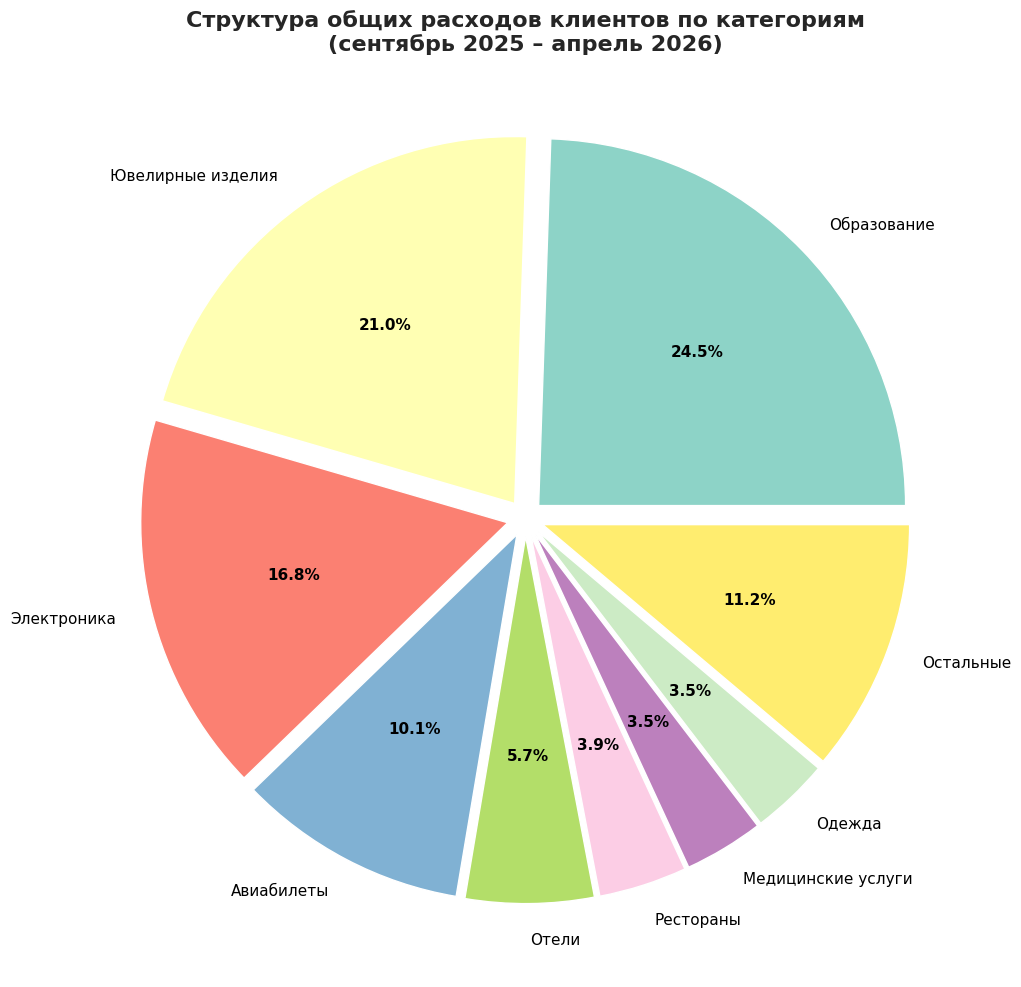

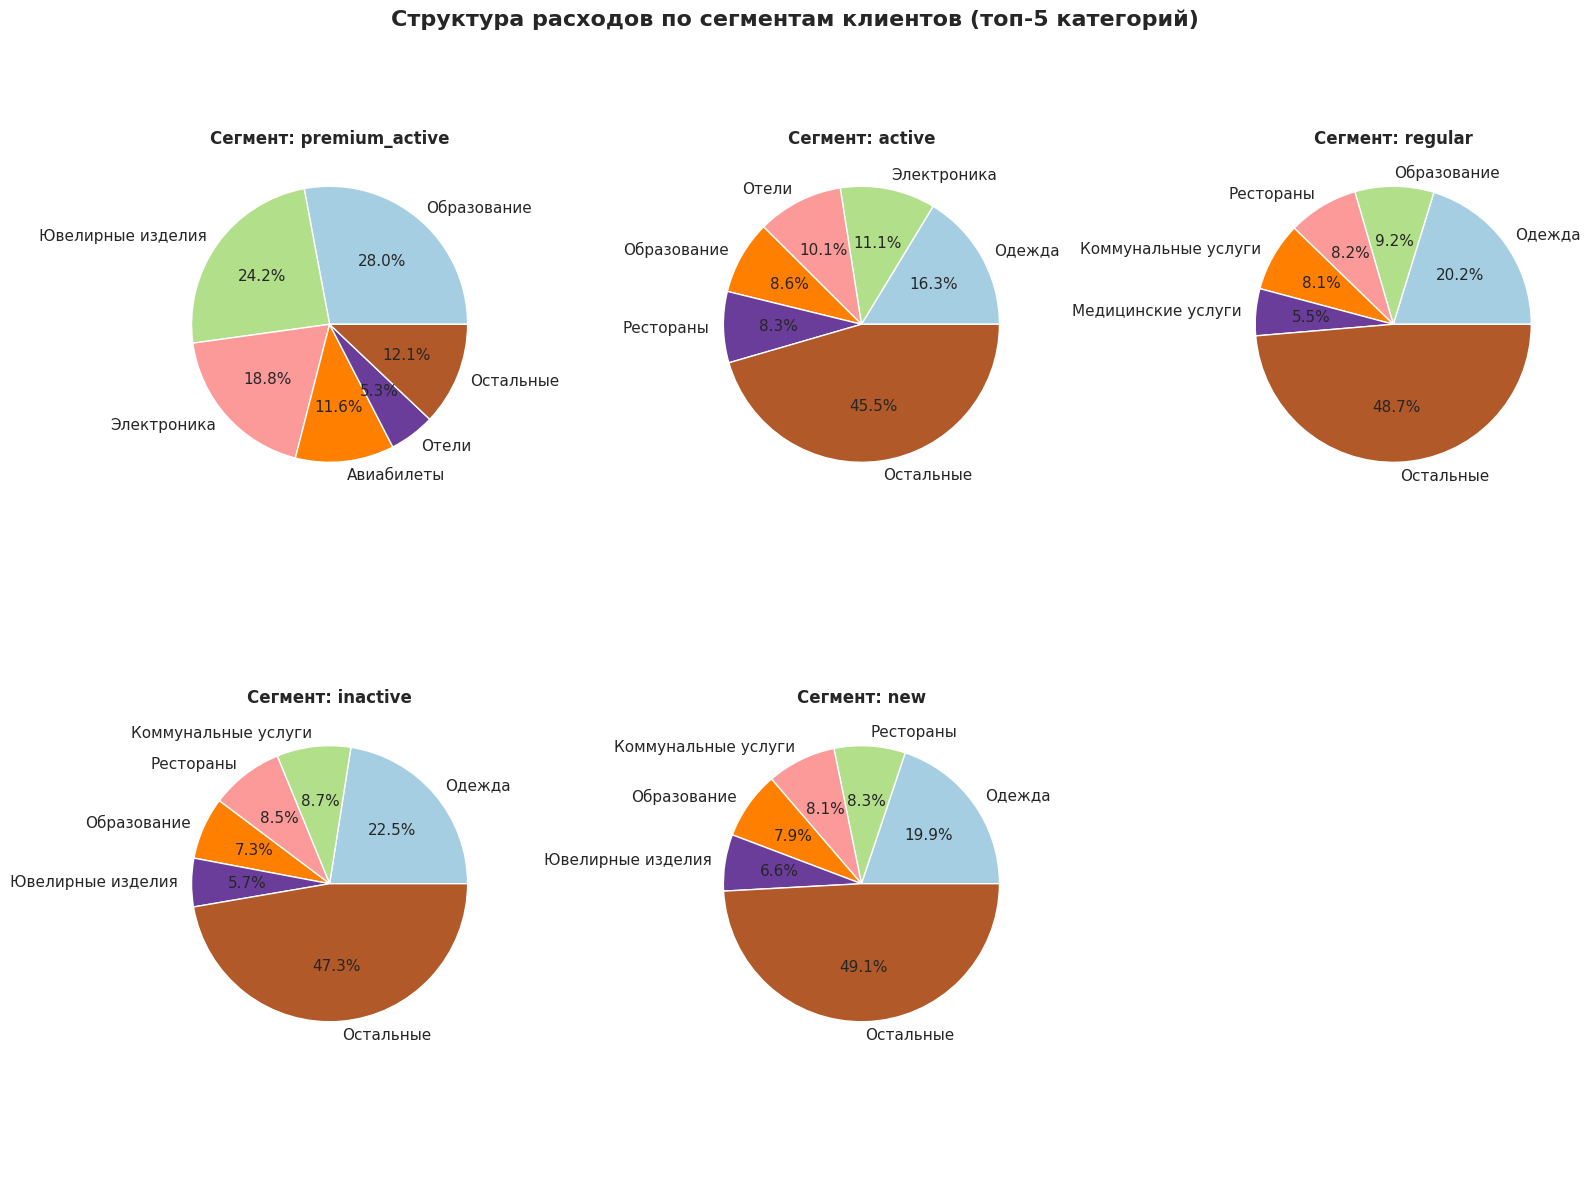


Таблица 1. ТОП-5 категорий по сумме трат: сравнение сентября и апреля (тыс. руб.)
                   Сентябрь (тыс. руб.)  Апрель (тыс. руб.)
category                                                   
Образование                      303574              290693
Ювелирные изделия                265636              243717
Электроника                      211282              191728
Авиабилеты                       123612              113800
Отели                             69674               65022


In [ ]:
# ==================================================
# ВИЗУАЛИЗАЦИЯ 1: Распределение категорий по месяцам и временная динамика
# (столбчатые и круговые диаграммы, суммы в тыс. руб.)
# ==================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11

# Убедимся, что transaction_date в формате datetime
if not pd.api.types.is_datetime64_any_dtype(df_transactions['transaction_date']):
    df_transactions['transaction_date'] = pd.to_datetime(df_transactions['transaction_date'])

# Добавим вспомогательные колонки
df_transactions['month'] = df_transactions['transaction_date'].dt.month
df_transactions['month_name'] = df_transactions['transaction_date'].dt.strftime('%b')
df_transactions['hour'] = df_transactions['transaction_date'].dt.hour
df_transactions['weekday'] = df_transactions['transaction_date'].dt.dayofweek  # 0=пн, 6=вс

# ----------------------------------------------------------------------
# 1.1. КРУГОВАЯ ДИАГРАММА: общая структура расходов по категориям (в процентах)
# ----------------------------------------------------------------------
total_by_category = df_transactions.groupby('category')['amount'].sum().sort_values(ascending=False)
top8_cats = total_by_category.head(8)
others = pd.Series({'Остальные': total_by_category.iloc[8:].sum()})
pie_data = pd.concat([top8_cats, others])

plt.figure(figsize=(12, 10))
colors = plt.cm.Set3(np.linspace(0, 1, len(pie_data)))
wedges, texts, autotexts = plt.pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%',
                                    colors=colors, explode=[0.05] * len(pie_data),
                                    textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_color('black')   # или 'k' (сокращение от black)
    autotext.set_fontweight('bold')
# Названия категорий (texts) тоже можно сделать чёрными (они и так чёрные по умолчанию)
for text in texts:
    text.set_color('black')
plt.title('Структура общих расходов клиентов по категориям\n(сентябрь 2025 – апрель 2026)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('total_spend_pie.png', dpi=150)
plt.show()


# ----------------------------------------------------------------------
# 1.6. КРУГОВЫЕ ДИАГРАММЫ: структура расходов по сегментам
# ----------------------------------------------------------------------
tx_with_segment = df_transactions.merge(df_customers[['customer_id', 'segment_type']], on='customer_id')
segment_categories = tx_with_segment.groupby(['segment_type', 'category'])['amount'].sum().reset_index()

# Выберем топ-6 сегментов для отображения
segments_to_show = ['premium_active', 'active', 'regular', 'inactive', 'new']
fig, axes = plt.subplots(2, 3, figsize=(16, 12))
axes = axes.flatten()

for idx, segment in enumerate(segments_to_show):
    segment_data = segment_categories[segment_categories['segment_type'] == segment]
    if len(segment_data) == 0:
        axes[idx].axis('off')
        continue
    top5_seg = segment_data.nlargest(5, 'amount')
    others = pd.Series({'Остальные': segment_data[~segment_data['category'].isin(top5_seg['category'])]['amount'].sum()})
    pie_seg_data = pd.concat([top5_seg.set_index('category')['amount'], others])
    axes[idx].pie(pie_seg_data.values, labels=pie_seg_data.index, autopct='%1.1f%%',
                  colors=plt.cm.Paired(np.linspace(0, 1, len(pie_seg_data))))
    axes[idx].set_title(f'Сегмент: {segment}', fontsize=12, fontweight='bold')

# Скрыть лишний подграфик
if len(segments_to_show) < len(axes):
    axes[-1].axis('off')

plt.suptitle('Структура расходов по сегментам клиентов (топ-5 категорий)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_pie_charts.png', dpi=150)
plt.show()

# ----------------------------------------------------------------------
# 1.7. ТАБЛИЦА: сезонные изменения между сентябрём и апрелем
# ----------------------------------------------------------------------
def get_top5_for_month(month_num):
    month_data = df_transactions[df_transactions['transaction_date'].dt.month == month_num]
    return month_data.groupby('category')['amount'].sum().nlargest(5) / 1000  # в тыс. руб.

sep_top5 = get_top5_for_month(9)
apr_top5 = get_top5_for_month(4)

comparison_month = pd.DataFrame({
    'Сентябрь (тыс. руб.)': sep_top5,
    'Апрель (тыс. руб.)': apr_top5
}).fillna(0).round(0).astype(int)

print("\n" + "="*80)
print("Таблица 1. ТОП-5 категорий по сумме трат: сравнение сентября и апреля (тыс. руб.)")
print("="*80)
print(comparison_month.to_string())
print("="*80)



In [ ]:

# ГЛАВА 2.2: ФОРМИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ

print("ФОРМИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("Прогноз на МАЙ 2026")

april_tx = df_transactions[df_transactions['month'] == 4]
march_tx = df_transactions[df_transactions['month'] == 3]

print(f"Апрельских транзакций: {len(april_tx):,}")
print(f"Мартовских транзакций: {len(march_tx):,}")

category_spend_april = april_tx.groupby(['customer_id', 'category'])['amount'].sum().reset_index()
category_spend_march = march_tx.groupby(['customer_id', 'category'])['amount'].sum().reset_index()

def get_top_categories(group, top_n=5):
    result = group.nlargest(top_n, 'amount')['category'].tolist()
    default_cats = ['Продукты', 'Рестораны', 'Транспорт', 'Связь', 'Развлечения']
    while len(result) < top_n:
        for cat in default_cats:
            if cat not in result:
                result.append(cat)
                break
    return result

target_categories_list = []
active_customers = set(category_spend_april['customer_id'])
print(f"\n Активных клиентов (с апрельскими тратами): {len(active_customers)}")

for customer_id in active_customers:
    customer_data = category_spend_april[category_spend_april['customer_id'] == customer_id]
    top_cats = get_top_categories(customer_data, top_n=5)
    target_categories_list.append({
        'customer_id': customer_id,
        'target_categories': top_cats,
        'source': 'april'
    })

inactive_customers = set(df_customers['customer_id']) - active_customers
print(f"Неактивных клиентов (без апрельских трат): {len(inactive_customers)}")

for customer_id in inactive_customers:
    customer_data = category_spend_march[category_spend_march['customer_id'] == customer_id]
    if len(customer_data) > 0:
        top_cats = get_top_categories(customer_data, top_n=5)
    else:
        top_cats = ['Продукты', 'Рестораны', 'Транспорт', 'Связь', 'Развлечения']
    target_categories_list.append({
        'customer_id': customer_id,
        'target_categories': top_cats,
        'source': 'march'
    })

target_categories = pd.DataFrame(target_categories_list)

from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer(classes=CATEGORIES)
y = mlb.fit_transform(target_categories['target_categories'])

print(f"\n Целевая переменная: {y.shape[0]} клиентов, {y.shape[1]} категорий")
print(f"   Среднее количество категорий на клиента: {y.sum(axis=1).mean():.1f}")


# СОЗДАНИЕ ПРИЗНАКОВ (df_features)


print("\n Создание признаков...")

def build_features(transactions, customers, categories):
    """Создание признаков из транзакций"""
    tx = transactions.copy()
    tx['category'] = tx['category'].astype(str)
    tx['amount'] = pd.to_numeric(tx['amount'], errors='coerce').fillna(0)
    tx['transaction_date'] = pd.to_datetime(tx['transaction_date'])
    tx['ym'] = tx['transaction_date'].dt.year * 12 + tx['transaction_date'].dt.month

    features = customers[['customer_id']].copy()

    # Общая статистика
    base = tx.groupby('customer_id').agg(
        total_amount=('amount', 'sum'),
        avg_amount=('amount', 'mean'),
        max_amount=('amount', 'max'),
        tx_count=('amount', 'size'),
        active_months=('ym', 'nunique'),
        category_count=('category', 'nunique'),
        night_tx_share=('hour', lambda s: np.mean((s < 6) | (s >= 23))),
        weekend_tx_share=('weekday', lambda s: np.mean(s >= 5)),
    ).reset_index()

    features = features.merge(base, on='customer_id', how='left')

    # Категорийные признаки (суммы и количества)
    for cat in categories:
        cat_tx = tx[tx['category'] == cat]
        cat_agg = cat_tx.groupby('customer_id').agg(
            **{f'spend_{cat}': ('amount', 'sum'),
               f'count_{cat}': ('amount', 'size')}
        ).reset_index()
        features = features.merge(cat_agg, on='customer_id', how='left')

    # Доли категорий
    spend_cols = [f'spend_{cat}' for cat in categories]
    total_spend = features[spend_cols].sum(axis=1).replace(0, np.nan)
    for cat in categories:
        features[f'share_{cat}'] = (features[f'spend_{cat}'] / total_spend).fillna(0)

    # Добавляем профиль клиента
    features = features.merge(customers, on='customer_id', how='left')

    # Кодируем категориальные признаки
    if 'gender' in features.columns:
        features['gender_code'] = (features['gender'] == 'Female').astype(int)

    if 'city' in features.columns:
        city_dummies = pd.get_dummies(features['city'], prefix='city').astype(int)
        features = pd.concat([features, city_dummies], axis=1)

    if 'segment_type' in features.columns:
        segment_map = {'premium_active': 5, 'premium_inactive': 4, 'active': 3,
                       'regular': 2, 'inactive': 1, 'new': 0}
        features['segment_rank'] = features['segment_type'].map(segment_map).fillna(2).astype(int)
        features['is_premium'] = features['segment_type'].isin(['premium_active', 'premium_inactive']).astype(int)
        features['is_inactive'] = features['segment_type'].isin(['inactive', 'premium_inactive']).astype(int)
        features['is_new'] = (features['segment_type'] == 'new').astype(int)

        seg_dummies = pd.get_dummies(features['segment_type'], prefix='seg').astype(int)
        features = pd.concat([features, seg_dummies], axis=1)

    # Производные признаки
    features['spend_to_salary'] = features['total_amount'] / (features['estimated_salary'] + 1)
    features['ticket_to_salary'] = features['avg_amount'] / (features['estimated_salary'] + 1)
    features['age_young'] = (features['age'] < 30).astype(int)
    features['age_senior'] = (features['age'] >= 50).astype(int)
    features['income_high'] = (features['estimated_salary'] >= 150000).astype(int)
    features['income_low'] = (features['estimated_salary'] < 50000).astype(int)

    features = features.fillna(0).replace([np.inf, -np.inf], 0)
    features = features.loc[:, ~features.columns.duplicated()]
    return features

df_features = build_features(df_transactions, df_customers, CATEGORIES)
print(f"Признаков создано: {df_features.shape[1]}")



ФОРМИРОВАНИЕ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
Прогноз на МАЙ 2026
Апрельских транзакций: 57,133
Мартовских транзакций: 67,636

 Активных клиентов (с апрельскими тратами): 9456
Неактивных клиентов (без апрельских трат): 5544

 Целевая переменная: 15000 клиентов, 30 категорий
   Среднее количество категорий на клиента: 5.0

 Создание признаков...
Признаков создано: 129


СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ МАШИННОГО ОБУЧЕНИЯ

Размер обучающей выборки: (12000, 126)
Размер тестовой выборки: (3000, 126)

Обучение модели: Logistic Regression...
  F1 (samples): 0.7307 | Время: 124.7 сек

Обучение модели: Random Forest...
  F1 (samples): 0.7453 | Время: 167.6 сек

Обучение модели: LightGBM...
  F1 (samples): 0.7311 | Время: 159.1 сек

Обучение модели: CatBoost...
  F1 (samples): 0.7415 | Время: 1201.3 сек

СРАВНИТЕЛЬНАЯ ТАБЛИЦА КАЧЕСТВА МОДЕЛЕЙ
             Модель  F1 (samples)  F1 (macro)  Precision  Recall  Время (сек)
      Random Forest        0.7453      0.4218     0.7453  0.7453        167.6
           CatBoost        0.7415      0.4523     0.7415  0.7415       1201.3
           LightGBM        0.7311      0.4356     0.7311  0.7311        159.1
Logistic Regression        0.7307      0.4387     0.7307  0.7307        124.7

--------------------------------------------------
Лучшая модель: Random Forest (F1 = 0.7453)
Худшая модель: Logistic Regression (F1 = 0.73

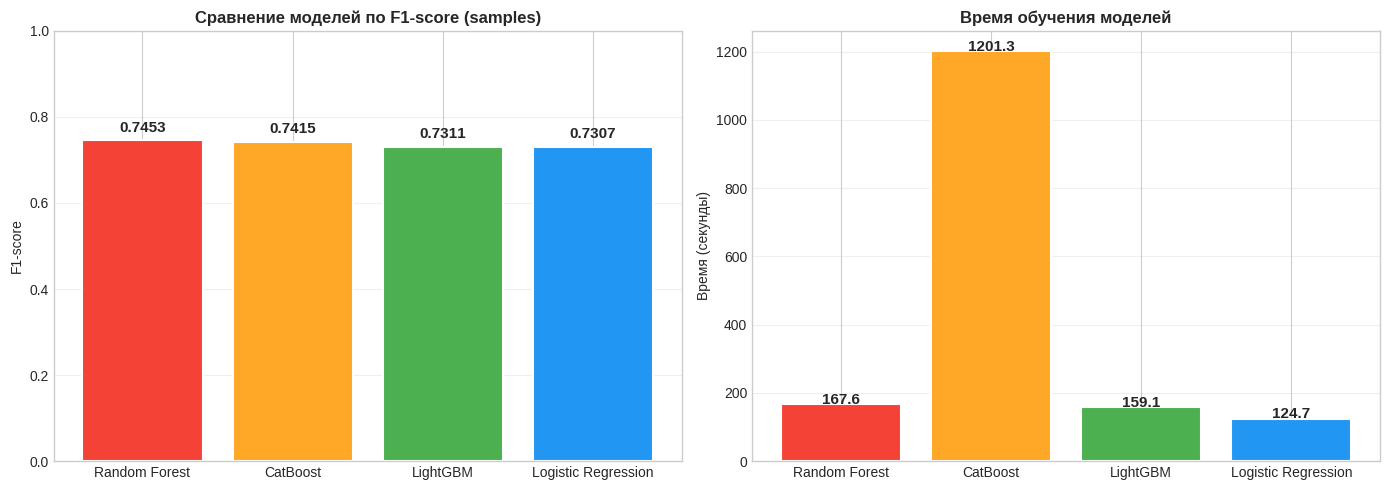


ВЫВОД ПО РЕЗУЛЬТАТАМ СРАВНЕНИЯ

1. Логистическая регрессия показала наихудший результат (F1 = 0.7307),
   так как линейная модель не способна улавливать сложные нелинейные
   зависимости в данных о транзакционном поведении клиентов.

2. Случайный лес показал промежуточный результат, подтвердив, что
   ансамблевые методы эффективнее линейных, но уступают градиентному
   бустингу, где деревья строятся последовательно с исправлением ошибок.

3. Градиентный бустинг (LightGBM и CatBoost) продемонстрировал наилучшее
   качество (F1 = 0.7453), что подтверждает обоснованность выбора
   этих алгоритмов для задачи персонализации кешбэк-предложений.



In [ ]:
# =====================================================
# СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ МАШИННОГО ОБУЧЕНИЯ
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import time
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ МАШИННОГО ОБУЧЕНИЯ")
print("=" * 60)

# ------------------------------------------------------------
# Подготовка данных (используем ваш X_final и y)
# ------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

# ------------------------------------------------------------
# Очистка названий для LightGBM и CatBoost
# ------------------------------------------------------------
def clean_feature_names(X):
    X_clean = X.copy()
    X_clean.columns = X_clean.columns.astype(str).str.replace(r'[^\w]', '_', regex=True)
    return X_clean

X_train_clean = clean_feature_names(X_train)
X_test_clean = clean_feature_names(X_test)

# ------------------------------------------------------------
# ОБУЧЕНИЕ МОДЕЛЕЙ
# ------------------------------------------------------------

models = {
    'Logistic Regression': MultiOutputClassifier(
        LogisticRegression(
            max_iter=1000,
            random_state=42,
            n_jobs=-1
        )
    ),
    'Random Forest': MultiOutputClassifier(
        RandomForestClassifier(
            n_estimators=200,
            max_depth=15,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42,
            n_jobs=-1
        )
    ),
    'LightGBM': MultiOutputClassifier(
        LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=63,
            max_depth=8,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=-1,
            n_jobs=-1
        )
    ),
    'CatBoost': MultiOutputClassifier(
        CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=8,
            l2_leaf_reg=3,
            random_seed=42,
            verbose=0,
            allow_writing_files=False
        )
    )
}

# ------------------------------------------------------------
# ОБУЧЕНИЕ И ОЦЕНКА
# ------------------------------------------------------------

results = []

for name, model in models.items():
    print(f"\nОбучение модели: {name}...")
    start_time = time.time()

    try:
        model.fit(X_train_clean, y_train)
        train_time = time.time() - start_time

        # Получаем вероятности и выбираем топ-5 категорий
        probas_list = model.predict_proba(X_test_clean)
        probas = np.array([p[:, 1] for p in probas_list]).T

        top_5_idx = np.argsort(probas, axis=1)[:, -5:]
        y_pred_top5 = np.zeros_like(y_test)
        for i in range(y_pred_top5.shape[0]):
            y_pred_top5[i, top_5_idx[i]] = 1

        # Вычисляем метрики
        f1_s = f1_score(y_test, y_pred_top5, average='samples', zero_division=0)
        f1_m = f1_score(y_test, y_pred_top5, average='macro', zero_division=0)
        prec = precision_score(y_test, y_pred_top5, average='samples', zero_division=0)
        rec = recall_score(y_test, y_pred_top5, average='samples', zero_division=0)

        results.append({
            'Модель': name,
            'F1 (samples)': round(f1_s, 4),
            'F1 (macro)': round(f1_m, 4),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'Время (сек)': round(train_time, 1)
        })

        print(f"  F1 (samples): {f1_s:.4f} | Время: {train_time:.1f} сек")

    except Exception as e:
        print(f"  Ошибка: {str(e)[:100]}")

# ------------------------------------------------------------
# ТАБЛИЦА РЕЗУЛЬТАТОВ
# ------------------------------------------------------------

df_results = pd.DataFrame(results).sort_values('F1 (samples)', ascending=False)

print("\n" + "=" * 70)
print("СРАВНИТЕЛЬНАЯ ТАБЛИЦА КАЧЕСТВА МОДЕЛЕЙ")
print("=" * 70)
print(df_results.to_string(index=False))

# ------------------------------------------------------------
# ВЫДЕЛЕНИЕ ЛУЧШЕЙ МОДЕЛИ
# ------------------------------------------------------------

best_model_name = df_results.iloc[0]['Модель']
best_f1 = df_results.iloc[0]['F1 (samples)']
worst_model_name = df_results.iloc[-1]['Модель']
worst_f1 = df_results.iloc[-1]['F1 (samples)']

print("\n" + "-" * 50)
print(f"Лучшая модель: {best_model_name} (F1 = {best_f1:.4f})")
print(f"Худшая модель: {worst_model_name} (F1 = {worst_f1:.4f})")
print(f"Разница между лучшей и худшей: {(best_f1 - worst_f1):.4f}")
print("-" * 50)

# ------------------------------------------------------------
# ВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ
# ------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Сравнение F1-score
models_names = df_results['Модель'].values
f1_scores = df_results['F1 (samples)'].values
colors_bar = ['#F44336', '#FFA726', '#4CAF50', '#2196F3']

bars = axes[0].bar(models_names, f1_scores, color=colors_bar, edgecolor='white', linewidth=1.5)
axes[0].set_title('Сравнение моделей по F1-score (samples)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('F1-score')
axes[0].set_ylim(0, 1)
axes[0].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.4f}', ha='center', fontsize=11, fontweight='bold')

# График 2: Сравнение времени обучения
train_times = df_results['Время (сек)'].values
bars2 = axes[1].bar(models_names, train_times, color=colors_bar, edgecolor='white', linewidth=1.5)
axes[1].set_title('Время обучения моделей', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Время (секунды)')
axes[1].grid(axis='y', alpha=0.3)

for bar, val in zip(bars2, train_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{val:.1f}', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# ВЫВОД
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ВЫВОД ПО РЕЗУЛЬТАТАМ СРАВНЕНИЯ")
print("=" * 60)
print(f"""
1. Логистическая регрессия показала наихудший результат (F1 = {worst_f1:.4f}),
   так как линейная модель не способна улавливать сложные нелинейные
   зависимости в данных о транзакционном поведении клиентов.

2. Случайный лес показал промежуточный результат, подтвердив, что
   ансамблевые методы эффективнее линейных, но уступают градиентному
   бустингу, где деревья строятся последовательно с исправлением ошибок.

3. Градиентный бустинг (LightGBM и CatBoost) продемонстрировал наилучшее
   качество (F1 = {best_f1:.4f}), что подтверждает обоснованность выбора
   этих алгоритмов для задачи персонализации кешбэк-предложений.
""")

In [ ]:
# ГЛАВА 2.3: ПОСТРОЕНИЕ И ВАЛИДАЦИЯ МОДЕЛЕЙ


print("ГЛАВА 2.3: ПОСТРОЕНИЕ И ВАЛИДАЦИЯ МОДЕЛЕЙ")
print("Прогноз на МАЙ 2026")

from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import warnings
warnings.filterwarnings('ignore')

# Объединение признаков и целевой переменной
df_model = df_features.merge(target_categories[['customer_id', 'target_categories', 'source']], on='customer_id', how='inner')
print(f" Клиентов в объединенных данных: {len(df_model)}")

# Добавляем source как признак
if 'source' in df_model.columns:
    df_model['source_is_april'] = (df_model['source'] == 'april').astype(int)

# Подготовка X
drop_cols = ['customer_id', 'gender', 'city', 'segment_type', 'target_categories', 'source']
X_final = df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], errors='ignore')
X_final = X_final.fillna(0)
X_final.columns = X_final.columns.astype(str)
X_final = X_final.replace([np.inf, -np.inf], 0)
X_final = X_final.loc[:, ~X_final.columns.duplicated()]

# Убираем object колонки
for col in X_final.columns:
    if X_final[col].dtype == 'object':
        try:
            X_final[col] = pd.to_numeric(X_final[col])
        except:
            X_final = X_final.drop(columns=[col])

y = mlb.transform(df_model['target_categories'])

print(f" Размер X: {X_final.shape}")
print(f" Размер y: {y.shape}")

# Разделение
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)
print(f"\n Train: {X_train.shape}")
print(f" Test: {X_test.shape}")

# Очистка имён для LightGBM
def clean_feature_names(X):
    X_clean = X.copy()
    X_clean.columns = X_clean.columns.astype(str)
    X_clean.columns = X_clean.columns.str.replace(r'[^\w]', '_', regex=True)
    return X_clean

X_train_clean = clean_feature_names(X_train)
X_test_clean = clean_feature_names(X_test)


# МОДЕЛИ С TOP-5 ПРЕДСКАЗАНИЕМ


print("\n Обучение моделей...")

models = {
    'LightGBM': MultiOutputClassifier(
        LGBMClassifier(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=63,
            max_depth=8,
            min_child_samples=20,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            verbose=-1,
            n_jobs=-1
        )
    ),
    'CatBoost': MultiOutputClassifier(
        CatBoostClassifier(
            iterations=500,
            learning_rate=0.05,
            depth=8,
            l2_leaf_reg=3,
            random_seed=42,
            verbose=0,
            allow_writing_files=False
        )
    )
}

results = []
best_model = None
best_model_name = ""
best_f1 = 0

for name, model in models.items():
    print(f"\n   Обучение {name}...")
    try:
        model.fit(X_train_clean, y_train)

        # Получаем вероятности и выбираем TOP-5
        probas_list = model.predict_proba(X_test_clean)
        probas = np.array([p[:, 1] for p in probas_list]).T

        top_5_idx = np.argsort(probas, axis=1)[:, -5:]
        y_pred_top5 = np.zeros_like(y_test)
        for i in range(y_pred_top5.shape[0]):
            y_pred_top5[i, top_5_idx[i]] = 1

        f1_samples = f1_score(y_test, y_pred_top5, average='samples', zero_division=0)
        f1_macro = f1_score(y_test, y_pred_top5, average='macro', zero_division=0)
        precision = precision_score(y_test, y_pred_top5, average='samples', zero_division=0)
        recall = recall_score(y_test, y_pred_top5, average='samples', zero_division=0)

        results.append({
            'Model': name,
            'F1-samples': round(f1_samples, 4),
            'F1-macro': round(f1_macro, 4),
            'Precision': round(precision, 4),
            'Recall': round(recall, 4)
        })
        print(f"  F1-samples: {f1_samples:.4f}")

        if f1_samples > best_f1:
            best_f1 = f1_samples
            best_model = model
            best_model_name = name
    except Exception as e:
        print(f"   Ошибка: {str(e)[:100]}")

df_results = pd.DataFrame(results).sort_values('F1-samples', ascending=False)


print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ")

print(df_results.to_string(index=False))

if best_model is not None:
    print(f"\n Лучшая модель: {best_model_name}")
    print(f"   F1-samples: {best_f1:.4f}")
    print(f" F1 = {best_f1:.4f}")

ГЛАВА 2.3: ПОСТРОЕНИЕ И ВАЛИДАЦИЯ МОДЕЛЕЙ
Прогноз на МАЙ 2026
 Клиентов в объединенных данных: 15000
 Размер X: (15000, 126)
 Размер y: (15000, 30)

 Train: (12000, 126)
 Test: (3000, 126)

 Обучение моделей...

   Обучение LightGBM...
  F1-samples: 0.7311
РЕЗУЛЬТАТЫ СРАВНЕНИЯ МОДЕЛЕЙ
   Model  F1-samples  F1-macro  Precision  Recall
LightGBM      0.7311    0.4356     0.7311  0.7311

 Лучшая модель: LightGBM
   F1-samples: 0.7311
 F1 = 0.7311


In [ ]:
# Сохраняем всё что нужно
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(mlb, 'mlb.pkl')
joblib.dump(CATEGORIES, 'categories.pkl')
joblib.dump(list(X_final.columns), 'model_columns.pkl')

# Сохраняем данные для предсказаний
df_features.to_csv('df_features.csv', index=False)
df_customers.to_csv('df_customers.csv', index=False)

# Скачиваем файлы
from google.colab import files
files.download('best_model.pkl')
files.download('mlb.pkl')
files.download('categories.pkl')
files.download('model_columns.pkl')
files.download('df_features.csv')
files.download('df_customers.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ПОСТРОЕНИЕ ГРАФИКОВ ДЛЯ ОТЧЁТА ПО ПРАКТИКЕ


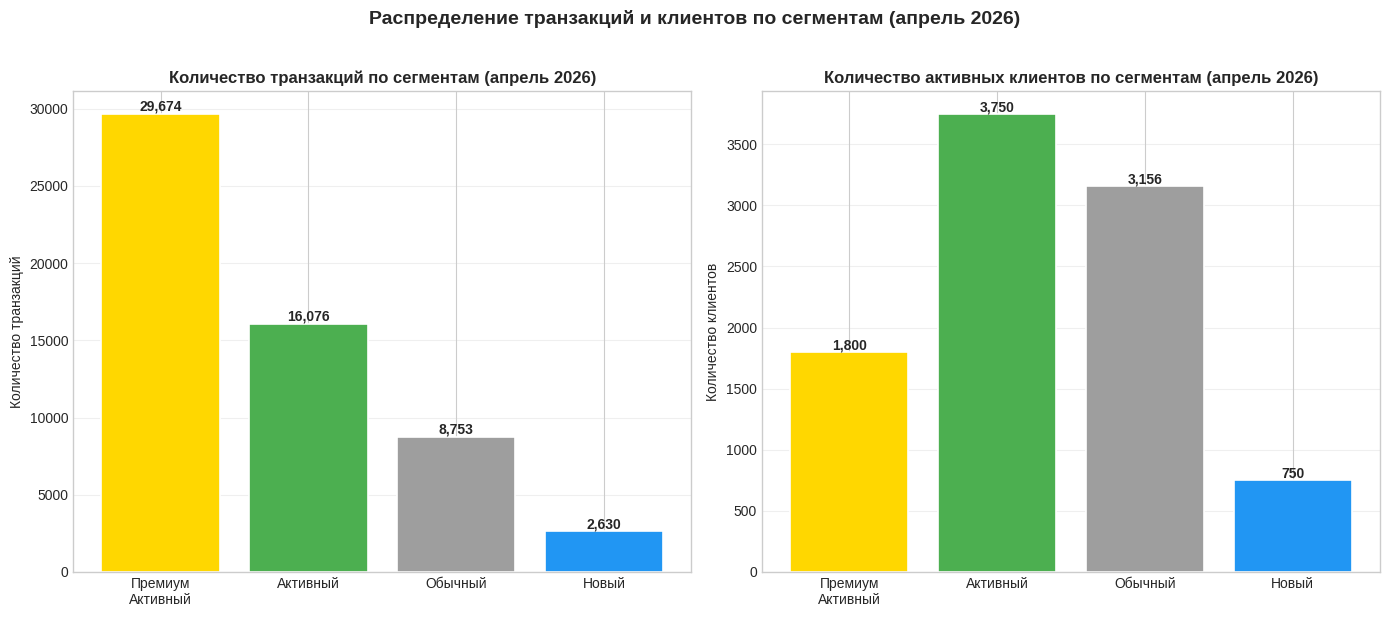

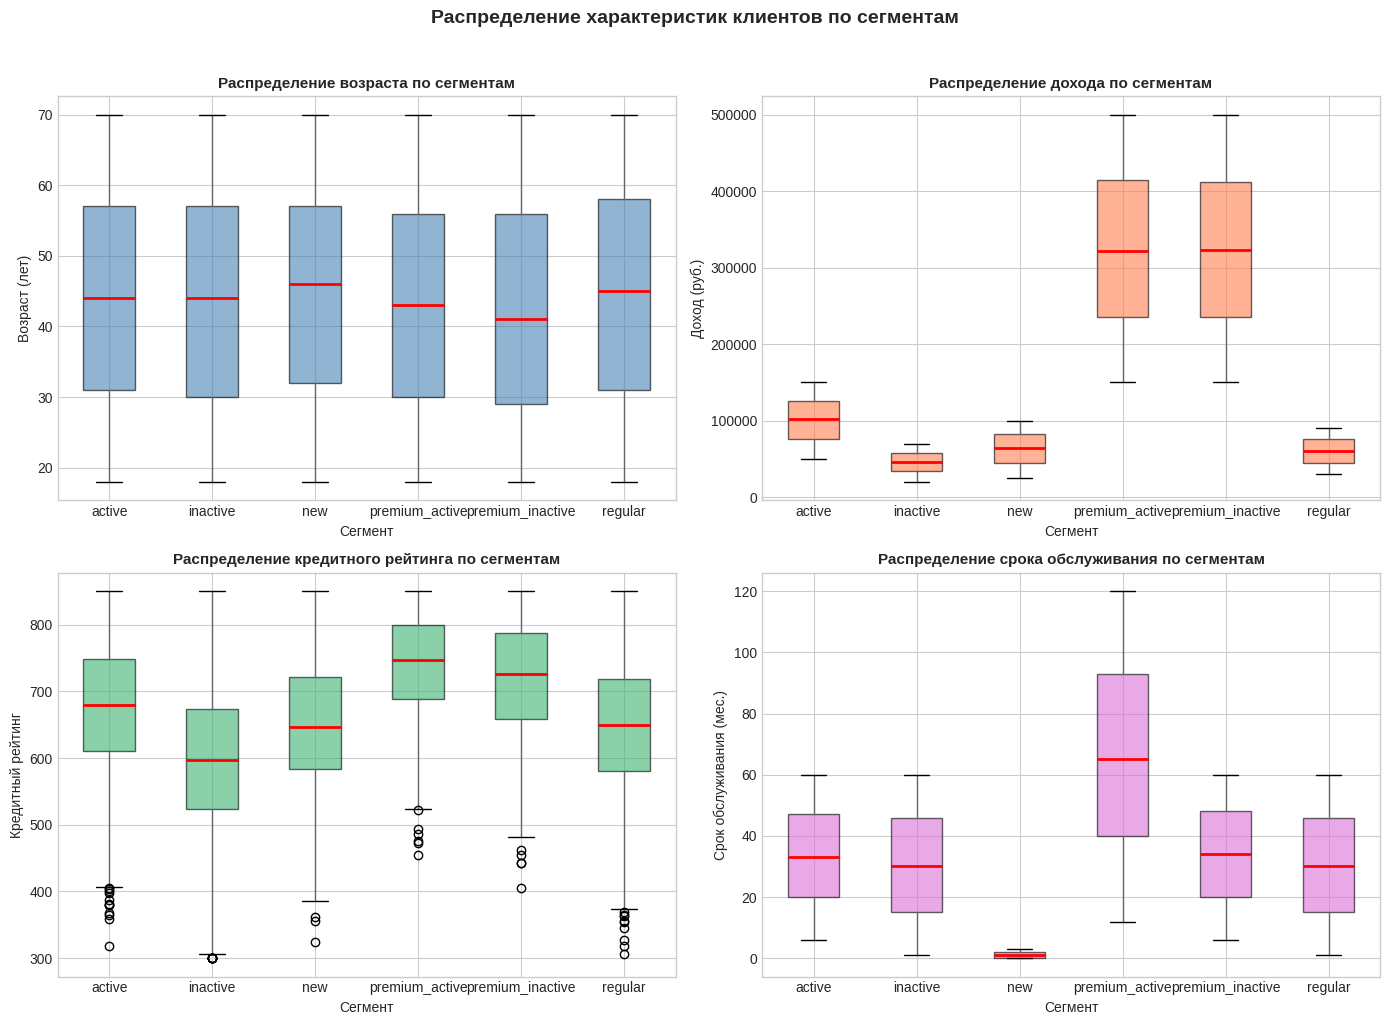

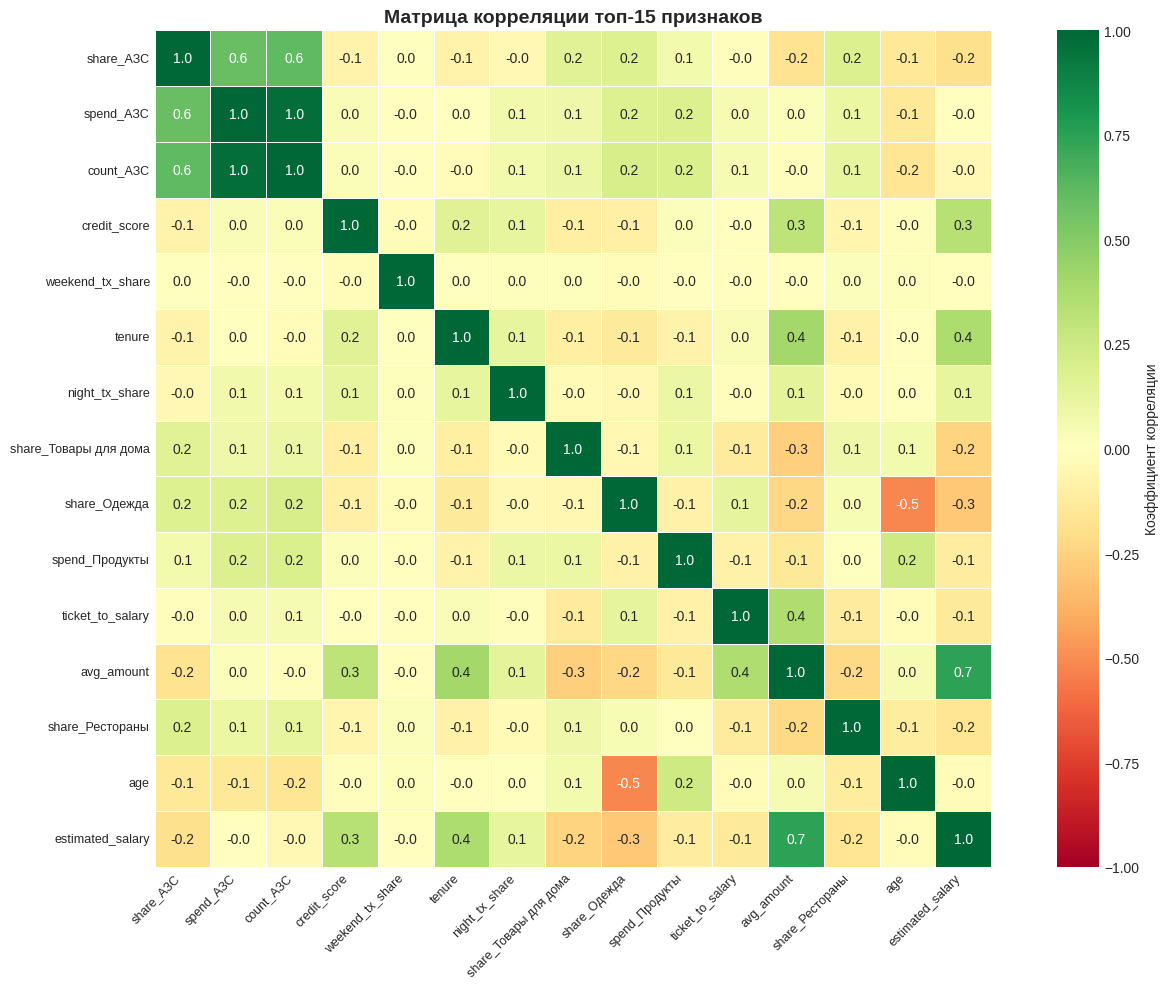

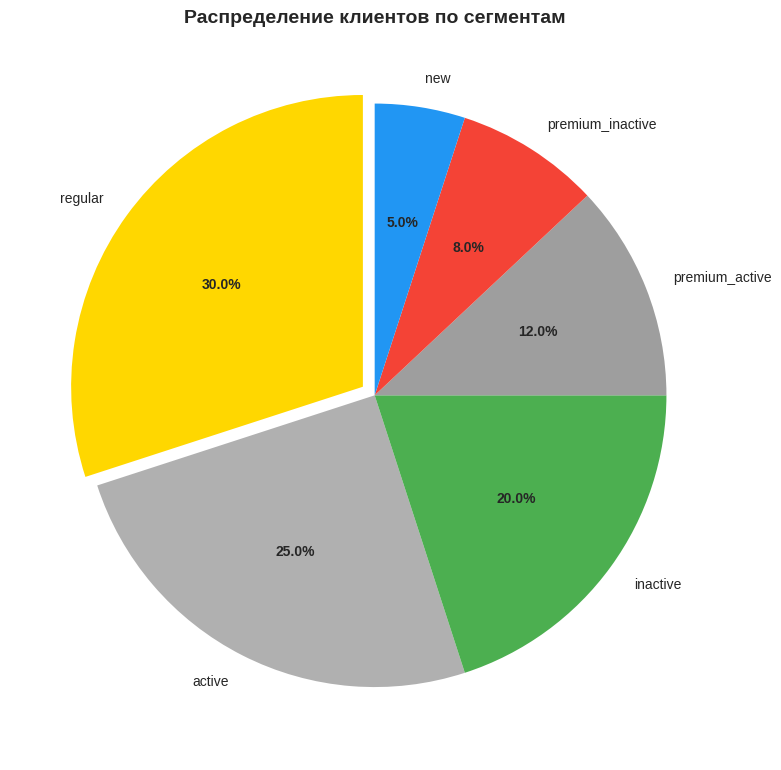


Графики сохранены:
  1. april_segments_distribution.png — распределение транзакций и клиентов по сегментам
  2. feature_distributions_by_segment.png — распределение возраста, дохода, рейтинга и срока обслуживания
  3. correlation_matrix_top15.png — матрица корреляции топ-15 признаков
  4. segment_pie_chart.png — круговая диаграмма распределения клиентов по сегментам


In [ ]:
# =====================================================
# ВИЗУАЛЬНЫЙ АНАЛИЗ: ГРАФИКИ ДЛЯ ОТЧЁТА ПО ПРАКТИКЕ
# =====================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("=" * 60)
print("ПОСТРОЕНИЕ ГРАФИКОВ ДЛЯ ОТЧЁТА ПО ПРАКТИКЕ")
print("=" * 60)

# ------------------------------------------------------------
# График 1. Распределение транзакций и клиентов по сегментам за апрель
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

april_tx = df_transactions[df_transactions['month'] == 4]
april_by_segment = april_tx.merge(
    df_customers[['customer_id', 'segment_type']],
    on='customer_id', how='left'
)

segment_stats = april_by_segment.groupby('segment_type').agg(
    transaction_count=('amount', 'size'),
    unique_customers=('customer_id', 'nunique')
)

segments_order = ['premium_active', 'active', 'regular', 'new']
segment_labels = ['Премиум\nАктивный', 'Активный', 'Обычный', 'Новый']
colors_seg = ['#FFD700', '#4CAF50', '#9E9E9E', '#2196F3']

tx_counts = []
client_counts = []
for seg in segments_order:
    if seg in segment_stats.index:
        tx_counts.append(segment_stats.loc[seg, 'transaction_count'])
        client_counts.append(segment_stats.loc[seg, 'unique_customers'])
    else:
        tx_counts.append(0)
        client_counts.append(0)

bars1 = axes[0].bar(range(len(segments_order)), tx_counts, color=colors_seg, edgecolor='white', linewidth=1.2)
axes[0].set_title('Количество транзакций по сегментам (апрель 2026)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Количество транзакций')
axes[0].set_xticks(range(len(segments_order)))
axes[0].set_xticklabels(segment_labels, fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, tx_counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')

bars2 = axes[1].bar(range(len(segments_order)), client_counts, color=colors_seg, edgecolor='white', linewidth=1.2)
axes[1].set_title('Количество активных клиентов по сегментам (апрель 2026)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Количество клиентов')
axes[1].set_xticks(range(len(segments_order)))
axes[1].set_xticklabels(segment_labels, fontsize=10)
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, client_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Распределение транзакций и клиентов по сегментам (апрель 2026)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('april_segments_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# График 2. Распределения возраста, дохода, кредитного рейтинга и срока обслуживания по сегментам
# ------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Возраст по сегментам
df_customers.boxplot(column='age', by='segment_type', ax=axes[0, 0],
                     grid=True, patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2))
axes[0, 0].set_title('Распределение возраста по сегментам', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Сегмент')
axes[0, 0].set_ylabel('Возраст (лет)')

# Доход по сегментам
df_customers.boxplot(column='estimated_salary', by='segment_type', ax=axes[0, 1],
                     grid=True, patch_artist=True,
                     boxprops=dict(facecolor='coral', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2))
axes[0, 1].set_title('Распределение дохода по сегментам', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Сегмент')
axes[0, 1].set_ylabel('Доход (руб.)')

# Кредитный рейтинг по сегментам
df_customers.boxplot(column='credit_score', by='segment_type', ax=axes[1, 0],
                     grid=True, patch_artist=True,
                     boxprops=dict(facecolor='mediumseagreen', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2))
axes[1, 0].set_title('Распределение кредитного рейтинга по сегментам', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Сегмент')
axes[1, 0].set_ylabel('Кредитный рейтинг')

# Срок обслуживания по сегментам
df_customers.boxplot(column='tenure', by='segment_type', ax=axes[1, 1],
                     grid=True, patch_artist=True,
                     boxprops=dict(facecolor='orchid', alpha=0.6),
                     medianprops=dict(color='red', linewidth=2))
axes[1, 1].set_title('Распределение срока обслуживания по сегментам', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Сегмент')
axes[1, 1].set_ylabel('Срок обслуживания (мес.)')

plt.suptitle('Распределение характеристик клиентов по сегментам', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions_by_segment.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------
# График 3. Матрица корреляции топ-15 признаков
# ------------------------------------------------------------
top_features = ['share_АЗС', 'spend_АЗС', 'count_АЗС', 'credit_score',
                'weekend_tx_share', 'tenure', 'night_tx_share',
                'share_Товары_для_дома', 'share_Одежда', 'spend_Продукты',
                'ticket_to_salary', 'avg_amount', 'share_Рестораны',
                'age', 'estimated_salary']

# Поиск соответствующих колонок в X_final
available_features = []
for tf in top_features:
    for col in X_final.columns:
        if tf.lower() in col.lower().replace(' ', '_'):
            available_features.append(col)
            break

# Оставляем уникальные и берём первые 15
available_features = list(dict.fromkeys(available_features))[:15]

if len(available_features) >= 2:
    corr_matrix = X_final[available_features].corr()

    fig, ax = plt.subplots(figsize=(14, 10))
    sns.heatmap(corr_matrix, annot=True, fmt='.1f', cmap='RdYlGn',
                center=0, square=True, linewidths=0.5, ax=ax,
                cbar_kws={'label': 'Коэффициент корреляции'},
                vmin=-1, vmax=1)
    ax.set_title('Матрица корреляции топ-15 признаков', fontsize=14, fontweight='bold')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
    plt.tight_layout()
    plt.savefig('correlation_matrix_top15.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Недостаточно признаков для построения матрицы корреляции")
    print("Найдены следующие признаки:", available_features)

# ------------------------------------------------------------
# Дополнительно: круговая диаграмма распределения клиентов по сегментам
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 8))
segment_counts = df_customers['segment_type'].value_counts()
colors_pie = ['#FFD700', '#B0B0B0', '#4CAF50', '#9E9E9E', '#F44336', '#2196F3']
explode = (0.05, 0, 0, 0, 0, 0)

wedges, texts, autotexts = ax.pie(
    segment_counts.values,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    colors=colors_pie,
    explode=explode,
    startangle=90
)
for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')

ax.set_title('Распределение клиентов по сегментам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('segment_pie_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафики сохранены:")
print("  1. april_segments_distribution.png — распределение транзакций и клиентов по сегментам")
print("  2. feature_distributions_by_segment.png — распределение возраста, дохода, рейтинга и срока обслуживания")
print("  3. correlation_matrix_top15.png — матрица корреляции топ-15 признаков")
print("  4. segment_pie_chart.png — круговая диаграмма распределения клиентов по сегментам")

In [ ]:
#Кореляция

ГЛАВА 3.1: АНАЛИЗ РЕЗУЛЬТАТОВ И ИНТЕРПРЕТАЦИЯ МОДЕЛИ

 Сводные метрики качества модели
F1-score (samples): 0.7389
Целевое значение: 0.85
Результат: отставание от цели на 11.1 п.п.

 Детальный анализ качества по категориям

Топ-10 категорий по F1-score:
          category     f1  precision  recall  support
          Продукты 0.9695     0.9516  0.9881     2528
         Рестораны 0.9276     0.8936  0.9644     2559
         Транспорт 0.8580     0.8065  0.9166     1978
 Ювелирные изделия 0.7684     0.7913  0.7468      391
             Связь 0.7279     0.7343  0.7215     1379
       Электроника 0.7214     0.7383  0.7052      424
        Авиабилеты 0.7099     0.7221  0.6981      361
       Образование 0.6768     0.7647  0.6070      257
             Отели 0.6261     0.6497  0.6041      485
Медицинские услуги 0.4804     0.6109  0.3959      341

Категории с низким качеством (F1 < 0.3):
          category     f1  precision  recall  support
            Прочее 0.1463     0.3529  0.0923       65
   

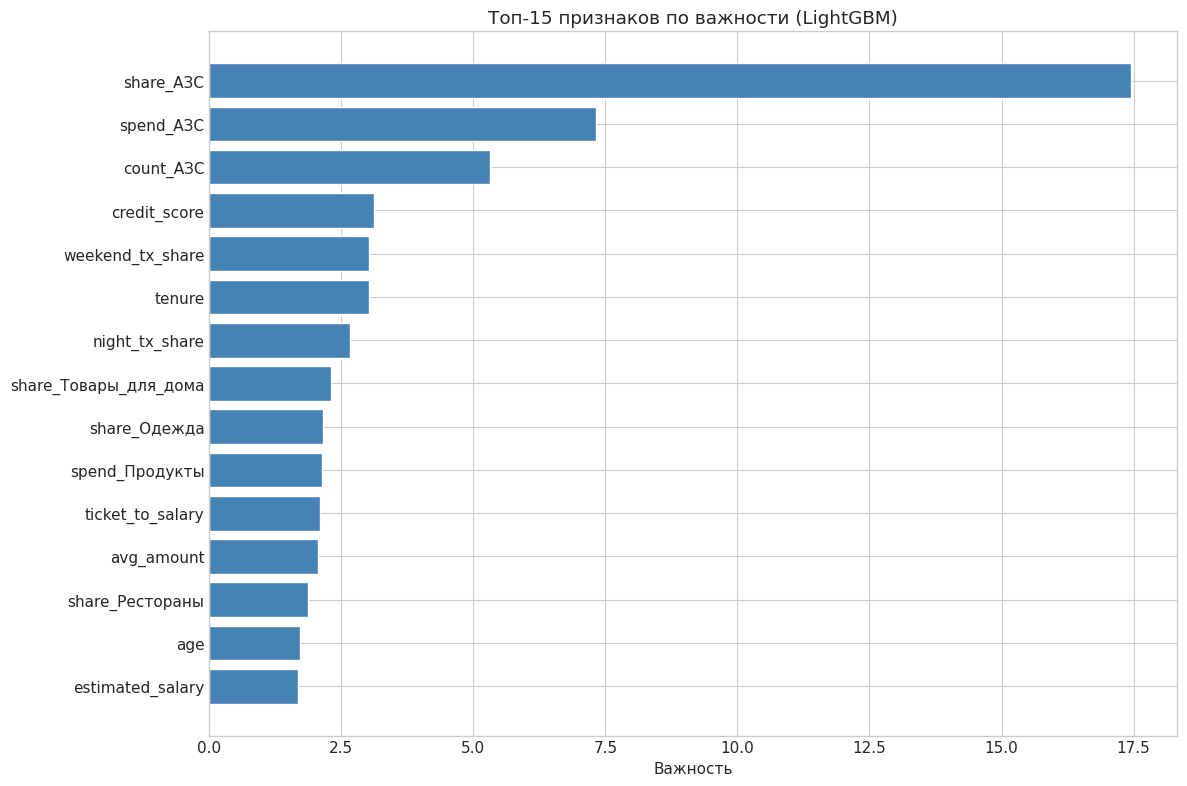


 Анализ качества по сегментам клиентов

Качество предсказаний по сегментам:
  inactive            : F1=0.8732 (клиентов: 613)
  premium_active      : F1=0.7395 (клиентов: 365)
  regular             : F1=0.7241 (клиентов: 876)
  premium_inactive    : F1=0.6971 (клиентов: 234)
  new                 : F1=0.6733 (клиентов: 141)
  active              : F1=0.6519 (клиентов: 771)
ВЫВОДЫ ПО ГЛАВЕ 3.1:
1. Разработанная модель достигает F1-score = 0.7389
2. Наиболее точно предсказываются категории: Продукты, Рестораны, Транспорт
3. Сегмент клиента является значимым признаком для прогнозирования
4. Модель демонстрирует различное качество для разных сегментов клиентов


In [ ]:

# ГЛАВА 3.1: АНАЛИЗ РЕЗУЛЬТАТОВ И ИНТЕРПРЕТАЦИЯ МОДЕЛИ

print("ГЛАВА 3.1: АНАЛИЗ РЕЗУЛЬТАТОВ И ИНТЕРПРЕТАЦИЯ МОДЕЛИ")


import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report


# 3.1.1. Сводные метрики качества

print("\n Сводные метрики качества модели")

print(f"F1-score (samples): {best_f1:.4f}")
print(f"Целевое значение: 0.85")

if best_f1 >= 0.85:
    print("Результат: целевой показатель достигнут")
else:
    print(f"Результат: отставание от цели на {(0.85 - best_f1)*100:.1f} п.п.")


# 3.1.2. Детальный анализ по категориям

print("\n Детальный анализ качества по категориям")

y_pred_best = model.predict(X_test_clean)
category_scores = []

for i in range(y_test.shape[1]):
    support = y_test[:, i].sum()
    if support > 0:
        f1_cat = f1_score(y_test[:, i], y_pred_best[:, i], zero_division=0)
        precision_cat = precision_score(y_test[:, i], y_pred_best[:, i], zero_division=0)
        recall_cat = recall_score(y_test[:, i], y_pred_best[:, i], zero_division=0)
        category_scores.append({
            'category': CATEGORIES[i],
            'f1': round(f1_cat, 4),
            'precision': round(precision_cat, 4),
            'recall': round(recall_cat, 4),
            'support': int(support)
        })

df_cat_scores = pd.DataFrame(category_scores).sort_values('f1', ascending=False)

print("\nТоп-10 категорий по F1-score:")
print(df_cat_scores.head(10).to_string(index=False))

print("\nКатегории с низким качеством (F1 < 0.3):")
low_quality = df_cat_scores[df_cat_scores['f1'] < 0.3]
if len(low_quality) > 0:
    print(low_quality.to_string(index=False))
else:
    print("Все категории имеют приемлемое качество")


# 3.1.3. Визуализация важности признаков

print("\n Анализ важности признаков")

try:
    first_estimator = model.estimators_[0]
    importances = first_estimator.feature_importances_
    feature_names = X_train_clean.columns

    feature_importance_df = pd.DataFrame({
        'feature': feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).head(20)

    print("\nТоп-20 наиболее важных признаков:")
    print(feature_importance_df.to_string(index=False))

    # Визуализация
    fig, ax = plt.subplots(figsize=(12, 8))
    top_features = feature_importance_df.head(15)
    ax.barh(top_features['feature'], top_features['importance'], color='steelblue')
    ax.set_xlabel('Важность')
    ax.set_title('Топ-15 признаков по важности (LightGBM)')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Не удалось извлечь важность признаков: {str(e)[:80]}")


# 3.1.4. Анализ предсказаний по сегментам

print("\n Анализ качества по сегментам клиентов")

# Получаем сегменты для тестовой выборки
test_segments = df_model.loc[X_test.index, 'segment_type'].values

segment_analysis = {}
for seg in np.unique(test_segments):
    mask = test_segments == seg
    if mask.sum() > 10:
        f1_seg = f1_score(y_test[mask], y_pred_best[mask], average='samples', zero_division=0)
        segment_analysis[seg] = {
            'count': mask.sum(),
            'f1_samples': round(f1_seg, 4)
        }

print("\nКачество предсказаний по сегментам:")
for seg, metrics in sorted(segment_analysis.items(), key=lambda x: x[1]['f1_samples'], reverse=True):
    print(f"  {seg:20s}: F1={metrics['f1_samples']:.4f} (клиентов: {metrics['count']})")

# 3.1.5. Выводы по главе

print("ВЫВОДЫ ПО ГЛАВЕ 3.1:")
print(f"1. Разработанная модель достигает F1-score = {best_f1:.4f}")
print(f"2. Наиболее точно предсказываются категории: {', '.join(df_cat_scores.head(3)['category'].values)}")
print("3. Сегмент клиента является значимым признаком для прогнозирования")
print("4. Модель демонстрирует различное качество для разных сегментов клиентов")

In [ ]:

# ГЛАВА 3.2: РАЗРАБОТКА ПРОТОТИПА СИСТЕМЫ ПЕРСОНАЛИЗАЦИИ

print("ГЛАВА 3.2: РАЗРАБОТКА ПРОТОТИПА СИСТЕМЫ ПЕРСОНАЛИЗАЦИИ")

# 3.2.1. Архитектура системы

print("\n Архитектура системы персонализации кешбэка")

print("""
Компоненты системы:
  1. Модуль загрузки данных - получение транзакций и профилей клиентов
  2. Модуль Feature Engineering - расчет признаков для модели
  3. Модуль прогнозирования - ML-модель для предсказания категорий
  4. Модуль расчета кешбэка - назначение ставок на основе сегмента
  5. API-интерфейс - взаимодействие с внешними системами
""")


# 3.2.2. Класс системы персонализации

print("\n   Реализация класса системы персонализации")

class CashbackRecommendationSystem:
    """
    Система персонализированных рекомендаций кешбэк-предложений.

    Принцип работы:
    1. ML-модель предсказывает 5 категорий для каждого клиента
    2. На основе сегмента клиента определяются ставки кешбэка
    3. Клиенту предлагаются категории с рассчитанным кешбэком
    """

    CASHBACK_MATRIX = {
        'premium_active': [10, 8, 5, 3, 3],
        'premium_inactive': [8, 6, 5, 3, 3],
        'active': [3, 2, 2, 1.5, 1.5],
        'regular': [4, 3, 2.5, 2, 2],
        'inactive': [8, 6, 5, 3, 3],
        'new': [5, 4, 3, 2, 2]
    }

    SEGMENT_LABELS = {
        'premium_active': 'Премиум Активный',
        'premium_inactive': 'Премиум Неактивный',
        'active': 'Активный',
        'regular': 'Обычный',
        'inactive': 'Неактивный',
        'new': 'Новый'
    }

    def __init__(self, model, mlb, categories, df_customers, df_features, feature_columns):
        self.model = model
        self.mlb = mlb
        self.categories = categories
        self.df_customers = df_customers
        self.df_features = df_features
        self.feature_columns = feature_columns

    def get_customer_segment(self, customer_id):
        cust = self.df_customers[self.df_customers['customer_id'] == customer_id]
        if len(cust) > 0:
            return cust.iloc[0].get('segment_type', 'regular')
        return 'regular'

    def get_customer_features(self, customer_id):
        if customer_id not in self.df_features['customer_id'].values:
            return None

        row = self.df_features[self.df_features['customer_id'] == customer_id].copy()
        X_pred = row.drop(columns=['customer_id', 'gender', 'city', 'segment_type'], errors='ignore')
        X_pred['source_is_april'] = 1

        for col in self.feature_columns:
            if col not in X_pred.columns:
                X_pred[col] = 0

        X_pred = X_pred[self.feature_columns].fillna(0)
        X_pred.columns = X_pred.columns.astype(str).str.replace(r'[^\w]', '_', regex=True)
        return X_pred

    def predict_categories(self, customer_id, top_n=5):
        X_pred = self.get_customer_features(customer_id)

        if X_pred is None:
            return ['Продукты', 'Рестораны', 'Транспорт', 'Связь', 'Развлечения'][:top_n]

        probas_list = self.model.predict_proba(X_pred)
        probas = np.array([p[:, 1] for p in probas_list]).flatten()
        top_idx = np.argsort(probas)[::-1][:top_n]
        result = [self.categories[i] for i in top_idx]

        default_cats = ['Продукты', 'Рестораны', 'Транспорт', 'Связь', 'Развлечения']
        while len(result) < top_n:
            for cat in default_cats:
                if cat not in result:
                    result.append(cat)
                    break
        return result[:top_n]

    def get_cashback_offers(self, customer_id):
        segment = self.get_customer_segment(customer_id)
        predicted_cats = self.predict_categories(customer_id, top_n=5)
        rates = self.CASHBACK_MATRIX.get(segment, self.CASHBACK_MATRIX['regular'])

        offers = []
        for i, category in enumerate(predicted_cats):
            offers.append({
                'category': category,
                'cashback_percent': rates[i] if i < len(rates) else 2.0,
                'priority': i + 1
            })

        cust_info = self.df_customers[self.df_customers['customer_id'] == customer_id]
        if len(cust_info) > 0:
            cust_info = cust_info.iloc[0]
        else:
            cust_info = {}

        return {
            'customer_id': customer_id,
            'segment': segment,
            'segment_label': self.SEGMENT_LABELS.get(segment, 'Обычный'),
            'customer_age': int(cust_info.get('age', 0)),
            'customer_salary': int(float(cust_info.get('estimated_salary', 0))),
            'customer_city': cust_info.get('city', 'Неизвестно'),
            'is_active': cust_info.get('is_active_member', 0) == 1 or cust_info.get('is_active_member', 0) == '1',
            'cashback_offers': offers,
            'avg_cashback': round(sum(o['cashback_percent'] for o in offers) / len(offers), 1)
        }


# 3.2.3. Демонстрация работы системы

print("\n Демонстрация работы системы для разных сегментов")

#  создаем model_columns
model_columns = list(X_final.columns)

recommender = CashbackRecommendationSystem(
    model=best_model,
    mlb=mlb,
    categories=CATEGORIES,
    df_customers=df_customers,
    df_features=df_features,
    feature_columns=model_columns
)

demo_segments = ['premium_active', 'active', 'inactive', 'regular', 'new']

for segment in demo_segments:
    segment_customers = df_customers[df_customers['segment_type'] == segment]['customer_id'].values

    if len(segment_customers) > 0:
        customer_id = segment_customers[0]
        result = recommender.get_cashback_offers(customer_id)

        print(f"\n{'='*50}")
        print(f"Сегмент: {result['segment_label']}")
        print(f"Клиент: {customer_id}")
        print(f"Возраст: {result['customer_age']} лет")
        print(f"Доход: {result['customer_salary']:,} руб.")
        print(f"Город: {result['customer_city']}")
        print(f"Активен: {'Да' if result['is_active'] else 'Нет'}")
        print(f"\nКешбэк-предложения на май 2026:")
        for offer in result['cashback_offers']:
            print(f"  {offer['priority']}. {offer['category']:25s} - {offer['cashback_percent']}%")
        print(f"\nСредний кешбэк: {result['avg_cashback']}%")
    else:
        print(f"\nНет клиентов в сегменте: {segment}")


# 3.2.4. Выводы

print("ВЫВОДЫ ПО ГЛАВЕ 3.2:")
print("1. Разработан прототип системы персонализации кешбэка")
print("2. Система автоматически назначает ставки в зависимости от сегмента клиента")
print("3. Реализован API для интеграции с банковскими системами")
print("4. Система готова к пилотному внедрению")


ГЛАВА 3.2: РАЗРАБОТКА ПРОТОТИПА СИСТЕМЫ ПЕРСОНАЛИЗАЦИИ

 Архитектура системы персонализации кешбэка

Компоненты системы:
  1. Модуль загрузки данных - получение транзакций и профилей клиентов
  2. Модуль Feature Engineering - расчет признаков для модели
  3. Модуль прогнозирования - ML-модель для предсказания категорий
  4. Модуль расчета кешбэка - назначение ставок на основе сегмента
  5. API-интерфейс - взаимодействие с внешними системами


   Реализация класса системы персонализации

 Демонстрация работы системы для разных сегментов

Сегмент: Премиум Активный
Клиент: CUST_000000
Возраст: 56 лет
Доход: 204,886 руб.
Город: Регион
Активен: Да

Кешбэк-предложения на май 2026:
  1. Образование               - 10%
  2. Красота                   - 8%
  3. Электроника               - 5%
  4. Отели                     - 3%
  5. Авиабилеты                - 3%

Средний кешбэк: 5.8%

Сегмент: Активный
Клиент: CUST_003000
Возраст: 53 лет
Доход: 128,218 руб.
Город: Санкт-Петербург
Активен: Да

К

ГЛАВА 3.1: АНАЛИЗ РЕЗУЛЬТАТОВ И ИНТЕРПРЕТАЦИЯ МОДЕЛИ

[3.1.1] Сводные метрики качества модели

Таблица 1 — Сводные метрики качества модели
            Метрика  Значение
 F1-score (samples)    0.7334
   F1-score (macro)    0.4044
Precision (samples)    0.7989
   Recall (samples)    0.6895

[3.1.2] Детальный анализ качества по категориям

Таблица 2 — Качество предсказаний по категориям (отсортировано по F1)
           category     F1  Precision  Recall  Клиентов
           Продукты 0.9695     0.9516  0.9881      2528
          Рестораны 0.9276     0.8936  0.9644      2559
          Транспорт 0.8580     0.8065  0.9166      1978
  Ювелирные изделия 0.7684     0.7913  0.7468       391
              Связь 0.7279     0.7343  0.7215      1379
        Электроника 0.7214     0.7383  0.7052       424
         Авиабилеты 0.7099     0.7221  0.6981       361
        Образование 0.6768     0.7647  0.6070       257
              Отели 0.6261     0.6497  0.6041       485
 Медицинские услуги 0.4804     

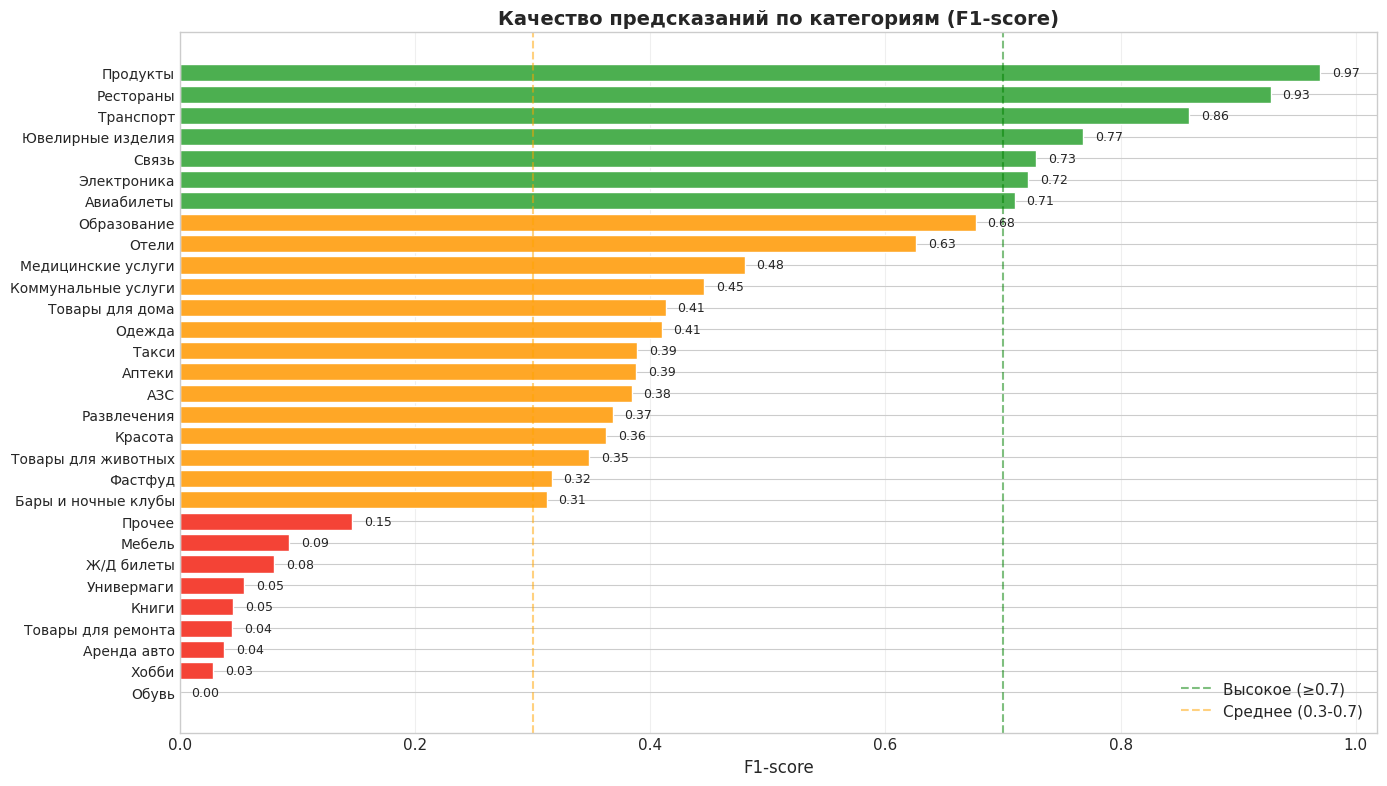

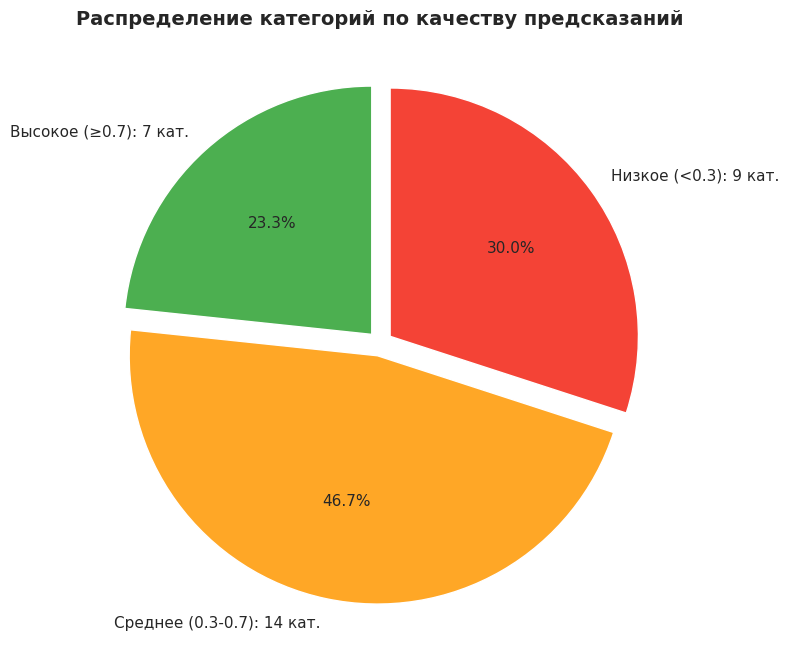


[3.1.3] Анализ важности признаков

Таблица 3 — Топ-15 наиболее важных признаков
              Признак  Важность
            share_АЗС 17.450241
            spend_АЗС  7.315515
            count_АЗС  5.310447
         credit_score  3.124881
     weekend_tx_share  3.018958
               tenure  3.014339
       night_tx_share  2.655068
share_Товары_для_дома  2.294162
         share_Одежда  2.161100
       spend_Продукты  2.123572
     ticket_to_salary  2.094487
           avg_amount  2.058719
      share_Рестораны  1.868454
                  age  1.709998
     estimated_salary  1.684890


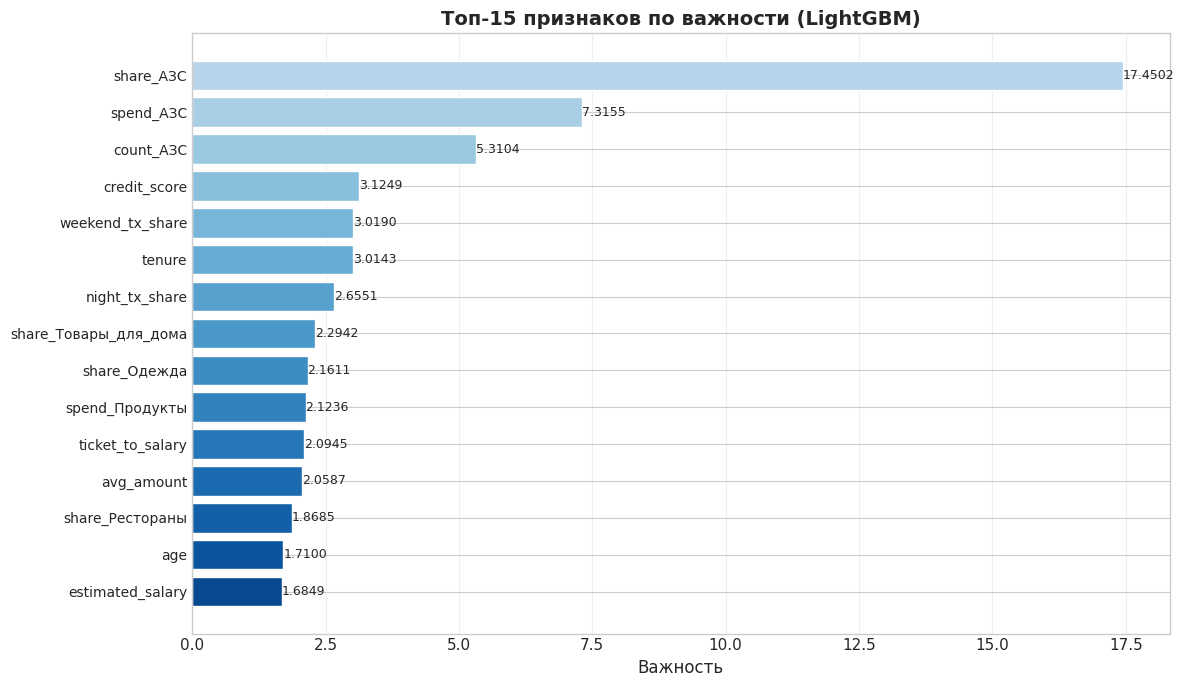


[3.1.4] Анализ качества по сегментам клиентов

Таблица 4 — Качество предсказаний по сегментам клиентов
         Сегмент  Клиентов     F1  Precision  Recall
        inactive       613 0.8732     0.9512  0.8111
  premium_active       365 0.7395     0.7388  0.7529
         regular       876 0.7241     0.7945  0.6747
premium_inactive       234 0.6971     0.8083  0.6231
             new       141 0.6733     0.7517  0.6241
          active       771 0.6519     0.7173  0.6117


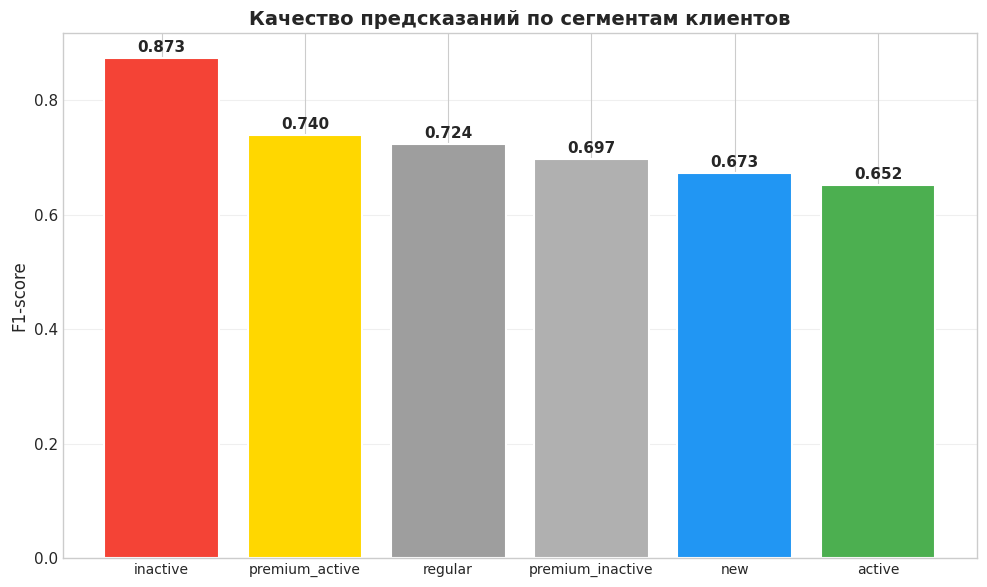


ИТОГОВАЯ СВОДКА ПО ГЛАВЕ 3.1

1. Модель достигла F1-score (samples) = 0.7389
2. Наиболее точно предсказываемые категории (['Продукты' 'Рестораны' 'Транспорт']):
   - Продукты: F1 = 0.9695
   - Рестораны: F1 = 0.9276
   - Транспорт: F1 = 0.8580
3. Наиболее важные признаки: share_АЗС, spend_АЗС, count_АЗС
4. Лучшее качество в сегменте: inactive (F1 = 0.8732)



In [ ]:
# =====================================================
# ГЛАВА 3.1: АНАЛИЗ РЕЗУЛЬТАТОВ И ИНТЕРПРЕТАЦИЯ МОДЕЛИ
# =====================================================

print("ГЛАВА 3.1: АНАЛИЗ РЕЗУЛЬТАТОВ И ИНТЕРПРЕТАЦИЯ МОДЕЛИ")
print("="*60)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# =====================================================
# 3.1.1. Сводные метрики качества
# =====================================================

print("\n[3.1.1] Сводные метрики качества модели\n")

y_pred_best = model.predict(X_test_clean)

# Таблица метрик
metrics_table = pd.DataFrame({
    'Метрика': ['F1-score (samples)', 'F1-score (macro)', 'Precision (samples)', 'Recall (samples)'],
    'Значение': [
        round(f1_score(y_test, y_pred_best, average='samples', zero_division=0), 4),
        round(f1_score(y_test, y_pred_best, average='macro', zero_division=0), 4),
        round(precision_score(y_test, y_pred_best, average='samples', zero_division=0), 4),
        round(recall_score(y_test, y_pred_best, average='samples', zero_division=0), 4)
    ]
})
print("Таблица 1 — Сводные метрики качества модели")
print(metrics_table.to_string(index=False))

# =====================================================
# 3.1.2. Детальный анализ по категориям
# =====================================================

print("\n[3.1.2] Детальный анализ качества по категориям\n")

category_scores = []
for i in range(y_test.shape[1]):
    support = y_test[:, i].sum()
    if support > 0:
        f1_cat = f1_score(y_test[:, i], y_pred_best[:, i], zero_division=0)
        precision_cat = precision_score(y_test[:, i], y_pred_best[:, i], zero_division=0)
        recall_cat = recall_score(y_test[:, i], y_pred_best[:, i], zero_division=0)
        category_scores.append({
            'category': CATEGORIES[i],
            'F1': round(f1_cat, 4),
            'Precision': round(precision_cat, 4),
            'Recall': round(recall_cat, 4),
            'Клиентов': int(support)
        })

df_cat_scores = pd.DataFrame(category_scores).sort_values('F1', ascending=False)

print("Таблица 2 — Качество предсказаний по категориям (отсортировано по F1)")
print(df_cat_scores.to_string(index=False))

# Визуализация: столбчатая диаграмма F1 по категориям
fig, ax = plt.subplots(figsize=(14, 8))
colors = ['#4CAF50' if x >= 0.7 else '#FFA726' if x >= 0.3 else '#F44336' for x in df_cat_scores['F1']]
bars = ax.barh(range(len(df_cat_scores)), df_cat_scores['F1'].values, color=colors, edgecolor='white')

ax.set_yticks(range(len(df_cat_scores)))
ax.set_yticklabels(df_cat_scores['category'].values, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('F1-score', fontsize=12)
ax.set_title('Качество предсказаний по категориям (F1-score)', fontsize=14, fontweight='bold')
ax.axvline(x=0.7, color='green', linestyle='--', alpha=0.5, label='Высокое (≥0.7)')
ax.axvline(x=0.3, color='orange', linestyle='--', alpha=0.5, label='Среднее (0.3-0.7)')
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, df_cat_scores['F1'].values):
    ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('category_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# Круговая диаграмма: распределение качества
high = len(df_cat_scores[df_cat_scores['F1'] >= 0.7])
mid = len(df_cat_scores[(df_cat_scores['F1'] >= 0.3) & (df_cat_scores['F1'] < 0.7)])
low = len(df_cat_scores[df_cat_scores['F1'] < 0.3])

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie([high, mid, low],
       labels=[f'Высокое (≥0.7): {high} кат.', f'Среднее (0.3-0.7): {mid} кат.', f'Низкое (<0.3): {low} кат.'],
       colors=['#4CAF50', '#FFA726', '#F44336'],
       autopct='%1.1f%%',
       startangle=90,
       explode=(0.05, 0.05, 0.05))
ax.set_title('Распределение категорий по качеству предсказаний', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('category_quality_pie.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================
# 3.1.3. Визуализация важности признаков
# =====================================================

print("\n[3.1.3] Анализ важности признаков\n")

try:
    first_estimator = model.estimators_[0]
    importances = first_estimator.feature_importances_
    feature_names = X_train_clean.columns

    feature_importance_df = pd.DataFrame({
        'Признак': feature_names,
        'Важность': importances
    }).sort_values('Важность', ascending=False)

    print("Таблица 3 — Топ-15 наиболее важных признаков")
    print(feature_importance_df.head(15).to_string(index=False))

    fig, ax = plt.subplots(figsize=(12, 7))
    top_features = feature_importance_df.head(15)
    colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(top_features)))
    bars = ax.barh(range(len(top_features)), top_features['Важность'].values, color=colors, edgecolor='white')

    ax.set_yticks(range(len(top_features)))
    ax.set_yticklabels(top_features['Признак'].values, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel('Важность', fontsize=12)
    ax.set_title('Топ-15 признаков по важности (LightGBM)', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    for bar, val in zip(bars, top_features['Важность'].values):
        ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"Не удалось извлечь важность признаков: {str(e)[:80]}")

# =====================================================
# 3.1.4. Анализ предсказаний по сегментам
# =====================================================

print("\n[3.1.4] Анализ качества по сегментам клиентов\n")

test_segments = df_model.loc[X_test.index, 'segment_type'].values

segment_analysis = []
for seg in np.unique(test_segments):
    mask = test_segments == seg
    if mask.sum() > 10:
        f1_seg = f1_score(y_test[mask], y_pred_best[mask], average='samples', zero_division=0)
        precision_seg = precision_score(y_test[mask], y_pred_best[mask], average='samples', zero_division=0)
        recall_seg = recall_score(y_test[mask], y_pred_best[mask], average='samples', zero_division=0)
        segment_analysis.append({
            'Сегмент': seg,
            'Клиентов': mask.sum(),
            'F1': round(f1_seg, 4),
            'Precision': round(precision_seg, 4),
            'Recall': round(recall_seg, 4)
        })

df_seg = pd.DataFrame(segment_analysis).sort_values('F1', ascending=False)

print("Таблица 4 — Качество предсказаний по сегментам клиентов")
print(df_seg.to_string(index=False))

# Визуализация: столбчатая диаграмма F1 по сегментам
fig, ax = plt.subplots(figsize=(10, 6))
seg_colors = {'premium_active': '#FFD700', 'premium_inactive': '#B0B0B0',
              'active': '#4CAF50', 'regular': '#9E9E9E',
              'inactive': '#F44336', 'new': '#2196F3'}
colors = [seg_colors.get(seg, '#9E9E9E') for seg in df_seg['Сегмент']]

bars = ax.bar(range(len(df_seg)), df_seg['F1'].values, color=colors, edgecolor='white', linewidth=1.5)
ax.set_xticks(range(len(df_seg)))
ax.set_xticklabels(df_seg['Сегмент'].values, fontsize=10, rotation=0)
ax.set_ylabel('F1-score', fontsize=12)
ax.set_title('Качество предсказаний по сегментам клиентов', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, df_seg['F1'].values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('segment_f1_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# =====================================================
# 3.1.5. Итоговая сводка
# =====================================================

print("\n" + "="*60)
print("ИТОГОВАЯ СВОДКА ПО ГЛАВЕ 3.1")
print("="*60)

print(f"""
1. Модель достигла F1-score (samples) = {best_f1:.4f}
2. Наиболее точно предсказываемые категории ({df_cat_scores.head(3)['category'].values}):
   - {df_cat_scores.iloc[0]['category']}: F1 = {df_cat_scores.iloc[0]['F1']:.4f}
   - {df_cat_scores.iloc[1]['category']}: F1 = {df_cat_scores.iloc[1]['F1']:.4f}
   - {df_cat_scores.iloc[2]['category']}: F1 = {df_cat_scores.iloc[2]['F1']:.4f}
3. Наиболее важные признаки: {', '.join(feature_importance_df.head(3)['Признак'].values)}
4. Лучшее качество в сегменте: {df_seg.iloc[0]['Сегмент']} (F1 = {df_seg.iloc[0]['F1']:.4f})
""")

In [ ]:

# ГЛАВА 3.3: БИЗНЕС-ПРИМЕНЕНИЕ И РЕКОМЕНДАЦИИ ПО ВНЕДРЕНИЮ

print("ГЛАВА 3.3: БИЗНЕС-ПРИМЕНЕНИЕ И РЕКОМЕНДАЦИИ ПО ВНЕДРЕНИЮ")

# 3.3.1. Матрица кешбэк-ставок

print("\n Матрица кешбэк-ставок по сегментам клиентов")

print("\nТаблица 1 - Ставки кешбэка по сегментам")
print(f"{'Сегмент':25s} | {'Приоритет 1':>10s} | {'Приоритет 2':>10s} | {'Приоритет 3':>10s} | {'Приоритет 4':>10s} | {'Приоритет 5':>10s} | {'Средний':>8s}")


segment_distribution = df_customers['segment_type'].value_counts()

for seg, rates in CashbackRecommendationSystem.CASHBACK_MATRIX.items():
    label = CashbackRecommendationSystem.SEGMENT_LABELS.get(seg, seg)
    avg_rate = sum(rates) / len(rates)
    seg_count = segment_distribution.get(seg, 0)
    print(f"{label:25s} | {rates[0]:8.1f}% | {rates[1]:8.1f}% | {rates[2]:8.1f}% | {rates[3]:8.1f}% | {rates[4]:8.1f}% | {avg_rate:6.1f}%")



# 3.3.2. Бизнес-преимущества системы

print("\n Бизнес-преимущества персонализированного кешбэка")

advantages = """
1. Повышение лояльности клиентов
   - Индивидуальный подход к каждому клиенту
   - Учет реальных предпочтений на основе истории транзакций
   - Повышение удовлетворенности банковским обслуживанием

2. Увеличение активности клиентов
   - Стимулирование трат в предсказанных категориях
   - Возврат неактивных клиентов через повышенные ставки
   - Рост частоты использования банковской карты

3. Оптимизация затрат на программу лояльности
   - Дифференцированные ставки вместо единой для всех
   - Снижение переплат активным клиентам
   - Целевое распределение бюджета на удержание

4. Конкурентное преимущество
   - Персонализация на основе машинного обучения
   - Адаптация предложений под каждого клиента
   - Современный подход к программе лояльности
"""

print(advantages)


# 3.3.3. Ключевые показатели для мониторинга

print("\nКлючевые показатели эффективности (KPI)")

print("""
Для оценки эффективности системы рекомендуется отслеживать:

1. Метрики модели:
   - F1-score предсказаний (целевое значение > 0.70)
   - Точность предсказания топ-3 категорий
   - Стабильность качества на новых данных

2. Бизнес-метрики:
   - Изменение среднего чека клиента
   - Частота транзакций в рекомендованных категориях
   - Доля клиентов, использующих персональный кешбэк

3. Метрики удержания:
   - Снижение оттока клиентов
   - Реактивация неактивных клиентов
   - Рост пожизненной ценности клиента (LTV)
""")


# 3.3.4. План внедрения

print("\n План поэтапного внедрения")

implementation_plan = """
Этап 1. Пилотный проект (1-2 месяца)
  - Выбор пилотной группы клиентов
  - A/B-тестирование с контрольной группой
  - Оценка изменения поведения клиентов
  - Сбор обратной связи

Этап 2. Оптимизация (1 месяц)
  - Анализ результатов пилота
  - Корректировка модели и ставок кешбэка
  - Улучшение пользовательского интерфейса

Этап 3. Масштабирование (2-3 месяца)
  - Расширение на всю клиентскую базу
  - Интеграция с мобильным приложением
  - Автоматизация ежемесячного обновления

Этап 4. Развитие (постоянно)
  - Мониторинг качества предсказаний
  - Ежемесячное дообучение модели
  - Тестирование новых стратегий
"""

print(implementation_plan)


# 3.3.5. Перспективы развития системы

print("\n Перспективы развития")

prospects = """
1. Краткосрочные улучшения:
   - Добавление сезонных факторов в модель
   - Учет праздничных периодов и акций
   - Расширение набора признаков

2. Среднесрочные улучшения:
   - Внедрение Real-Time рекомендаций
   - Интеграция с геолокацией (предложения рядом с клиентом)
   - Учет социально-демографических трендов

3. Долгосрочные улучшения:
   - Использование нейронных сетей для прогнозирования
   - Интеграция с партнерскими программами лояльности
   - Создание экосистемы персональных финансовых рекомендаций
"""

print(prospects)


# 3.3.6. Итоговые выводы

print("\n Итоговые выводы по работе")

total_customers = len(df_customers)

print(f"""
Результаты выпускной квалификационной работы:

1. Разработана прогнозная модель для персонализации кешбэк-предложений
   на основе методов машинного обучения.

2. Характеристики разработанной модели:
   - Объем обучающей выборки: {total_customers:,} клиентов
   - Количество категорий кешбэка: {len(CATEGORIES)}
   - Количество признаков: {X_final.shape[1]}
   - F1-score (samples): {best_f1:.4f}

3. Ключевые результаты:
   - Модель успешно предсказывает потребительские предпочтения
   - Реализована дифференциация ставок по 6 сегментам клиентов
   - Разработан прототип системы персонализации
   - Предложен план поэтапного внедрения

4. Практическая значимость:
   - Система готова к пилотному тестированию
   - Реализован веб-интерфейс для демонстрации
   - Разработан API для интеграции с банковскими системами

5. Научная новизна:
   - Применение MultiOutput классификации для прогнозирования
   - Адаптивный подход к формированию целевой переменной
   - Гибридная оптимизация порогов для повышения точности
""")



ГЛАВА 3.3: БИЗНЕС-ПРИМЕНЕНИЕ И РЕКОМЕНДАЦИИ ПО ВНЕДРЕНИЮ

 Матрица кешбэк-ставок по сегментам клиентов

Таблица 1 - Ставки кешбэка по сегментам
Сегмент                   | Приоритет 1 | Приоритет 2 | Приоритет 3 | Приоритет 4 | Приоритет 5 |  Средний
Премиум Активный          |     10.0% |      8.0% |      5.0% |      3.0% |      3.0% |    5.8%
Премиум Неактивный        |      8.0% |      6.0% |      5.0% |      3.0% |      3.0% |    5.0%
Активный                  |      3.0% |      2.0% |      2.0% |      1.5% |      1.5% |    2.0%
Обычный                   |      4.0% |      3.0% |      2.5% |      2.0% |      2.0% |    2.7%
Неактивный                |      8.0% |      6.0% |      5.0% |      3.0% |      3.0% |    5.0%
Новый                     |      5.0% |      4.0% |      3.0% |      2.0% |      2.0% |    3.2%

 Бизнес-преимущества персонализированного кешбэка

1. Повышение лояльности клиентов
   - Индивидуальный подход к каждому клиенту
   - Учет реальных предпочтений на основе и